In [160]:
import matplotlib.pyplot as plt
import numpy as np
import os, sys, alive_progress

from quantum_electron.electron_counter import FullModel, make_potential, find_minimum_location
from quantum_electron.schrodinger_solver import QuantumAnalysis
from quantum_electron.utils import xy2r, r2xy, crop_potential, find_nearest,  density_from_positions, select_outer_electrons

from zeroheliumkit.src.importing import Reader_DXF
from zeroheliumkit.fem import FieldAnalyzer
from zeroheliumkit.src.settings import *
import matplotlib.animation as animation

%matplotlib inline
%config InlineBackend.figure_format='retina'
%matplotlib widget
plot_config = {"anchors": CYAN,
               "0": BLUE,
               "EBEAMLITHO_GUARDS": ORANGE,
               "EBEAMLITHO_SMALLPADS": RED,
               "Pillar0": GREEN}
import zeroheliumkit 
from scipy.constants import elementary_charge as qe, epsilon_0 as eps0, electron_mass as me, Boltzmann as kB
from matplotlib import patheffects as pe

## Download the potential

./sim2/sample_resevoir_10x10_no_bond_lines.dxf // Layers : dict_keys(['EBEAMLITHO_SMALLPADS', '0', 'EBEAMLITHO_GUARDS'])


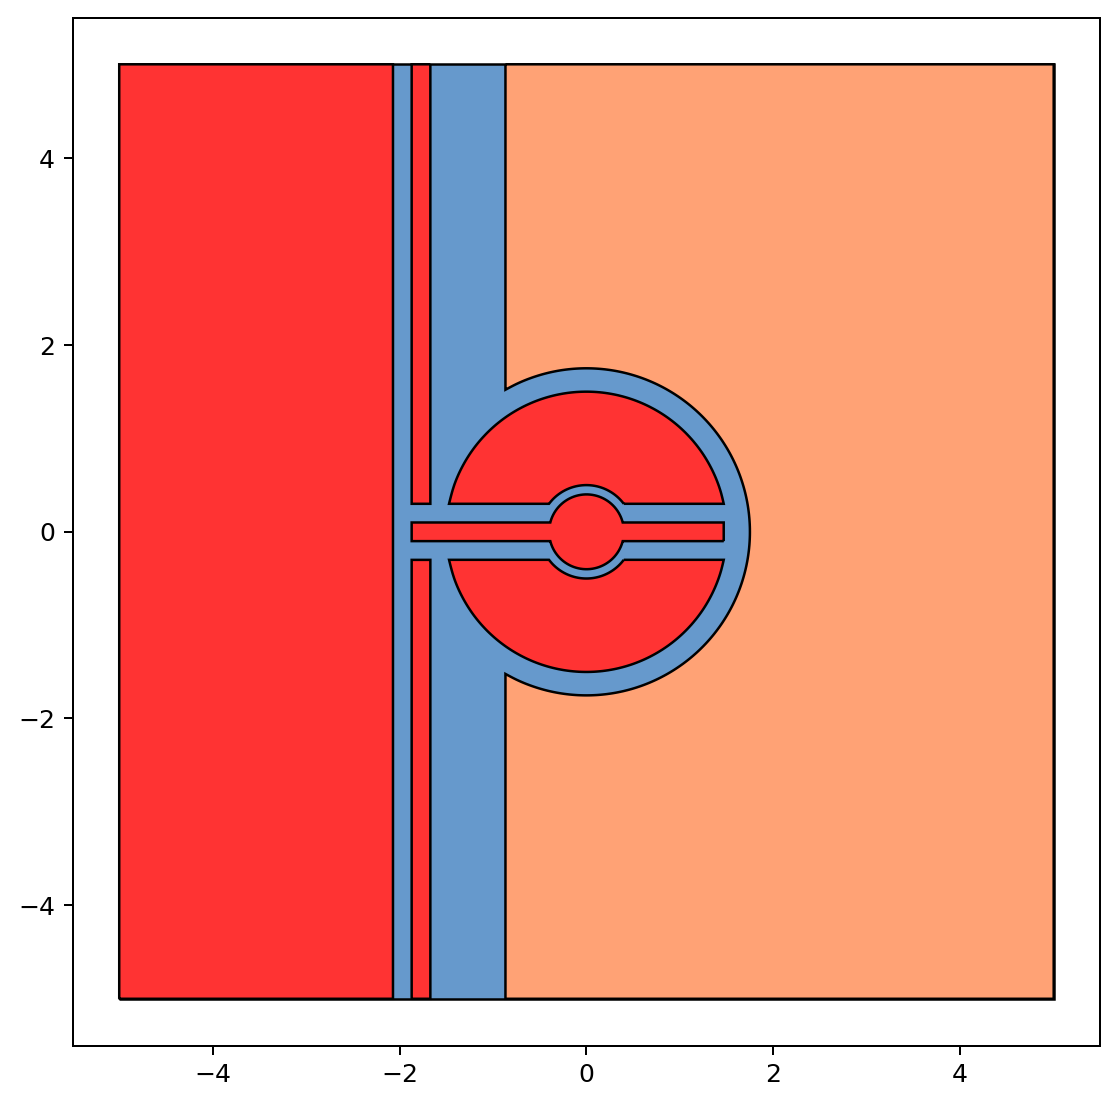

In [27]:
dirname = 'sim2/'
device = zeroheliumkit.GeomCollection(layers=Reader_DXF(r"./sim2/sample_resevoir_10x10_no_bond_lines.dxf").geometries)
device.quickplot(plot_config)
trap = FieldAnalyzer((dirname+'phi_xy.txt', 'dot', '2Dmap'))


In [5]:

print(f"Input data dx = {np.diff(trap.dot['xlist'])[0] * 1e3:.1f} nm")
print(f"Input data dy = {np.diff(trap.dot['ylist'])[0] * 1e3:.1f} nm")


Input data dx = 20.0 nm
Input data dy = 20.0 nm


## Choose the voltages
typical charge noise 100 uV (GaAs @Delft) 230 uV(Si @Delft) 70 uV (best Si) 8 uV (best GaAs) 

These values are dominated by the devices themselves, not from the electronics.

In [28]:
from quantum_electron.utils import crop_potential

voltages = {
    'half_donut_top':0.5,
    'half_donut_bottom':0.5,
    'gate_top':0.2,
    'gate_bottom':0.2,
    'reservoir':0.7,
    'center':0.6,
    'guard':-0.000,
}

for electrode in trap.dot.keys():
    if electrode == 'xlist' or electrode == 'ylist':
        break
    new_x, new_y, new_U = crop_potential(x=trap.dot['xlist'], y=trap.dot['ylist'], U=trap.dot[electrode],
                                         xrange=(-5, 2), yrange=(-4,4))

    trap.dot[electrode] = new_U

trap.dot['xlist'] = new_x
trap.dot['ylist'] = new_y

(-5.0, 2.0)

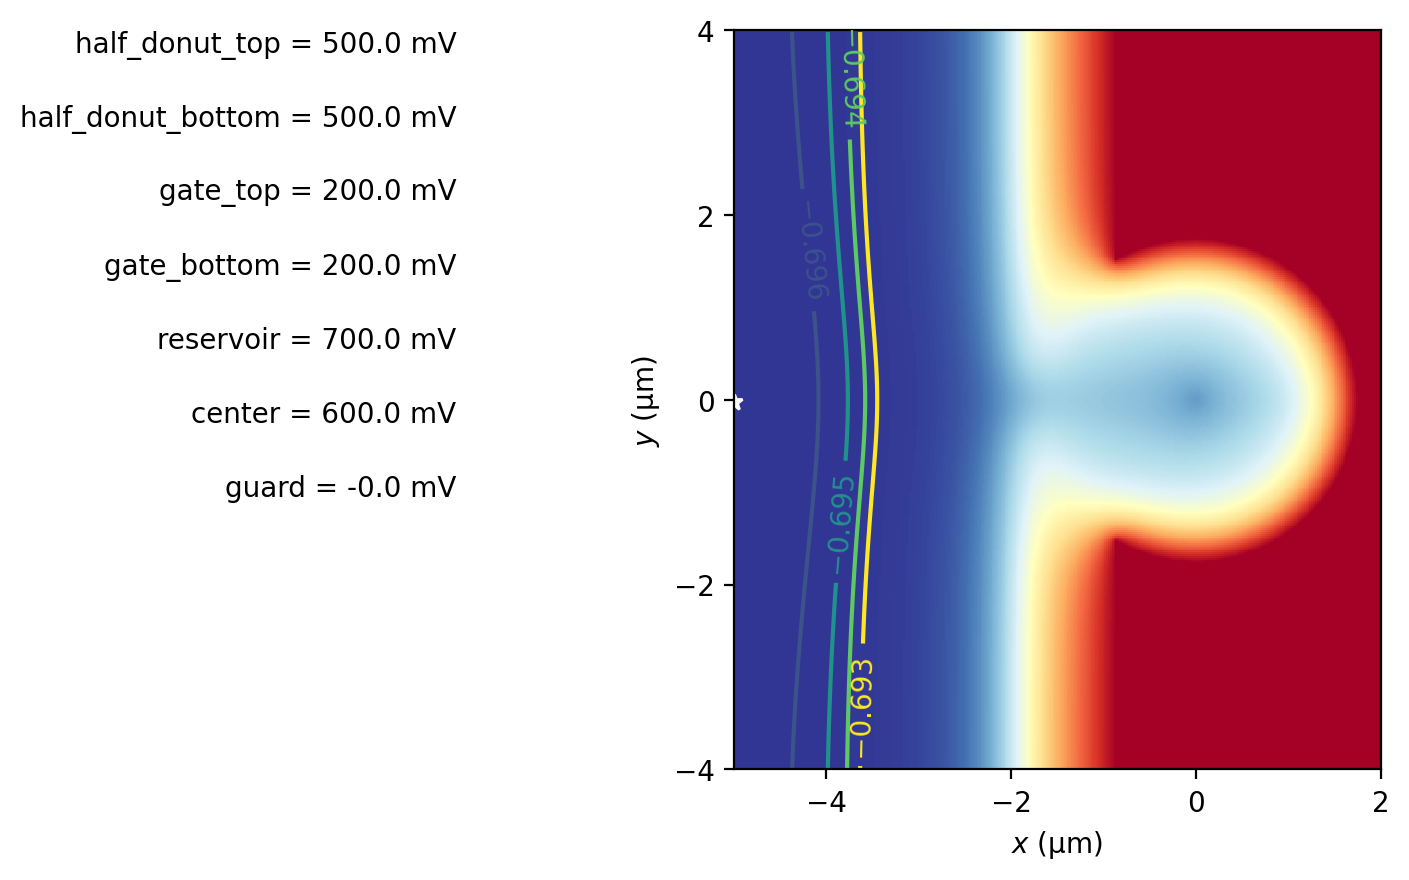

In [29]:
fig, ax = plt.subplots()
fm = FullModel(trap.dot, voltages)
fm.plot_potential_energy(ax=ax, coor=[0,0], dxdy=(10, 8))
ax.set_xlim(-5, 2)


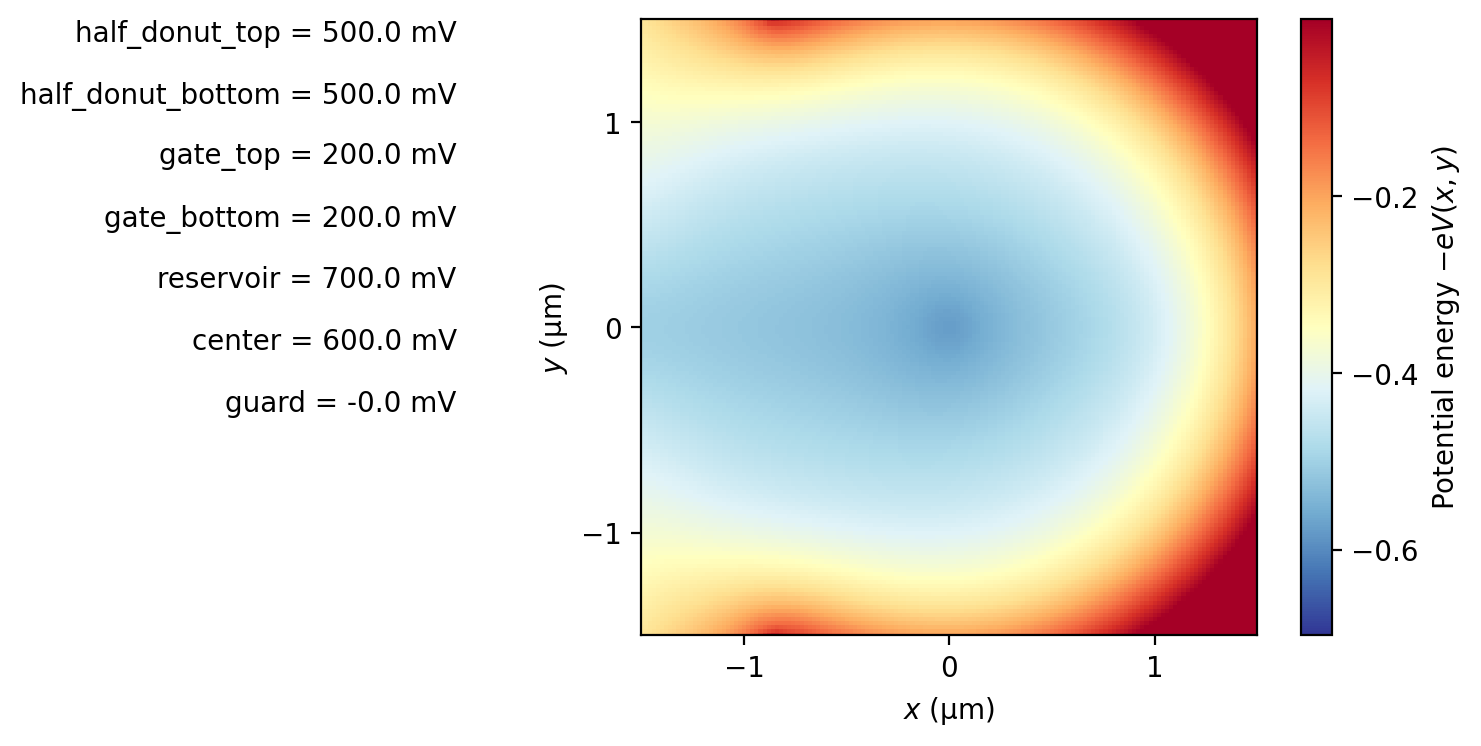

In [5]:
qa = QuantumAnalysis(trap.dot, voltages)

qa.plot_potential_energy(coor=(0, 0), dxdy=(3, 3))


max_ysol:1.45
y_com_max:-0.37718374758374196
max_ysol:1.45
y_com_max:1.370015429400424
max_ysol:1.45
y_com_max:-0.3759502942640569
max_ysol:1.45
y_com_max:1.368952249723831
max_ysol:1.45
y_com_max:-0.37478232333443806
max_ysol:1.45
y_com_max:1.3679294702890648


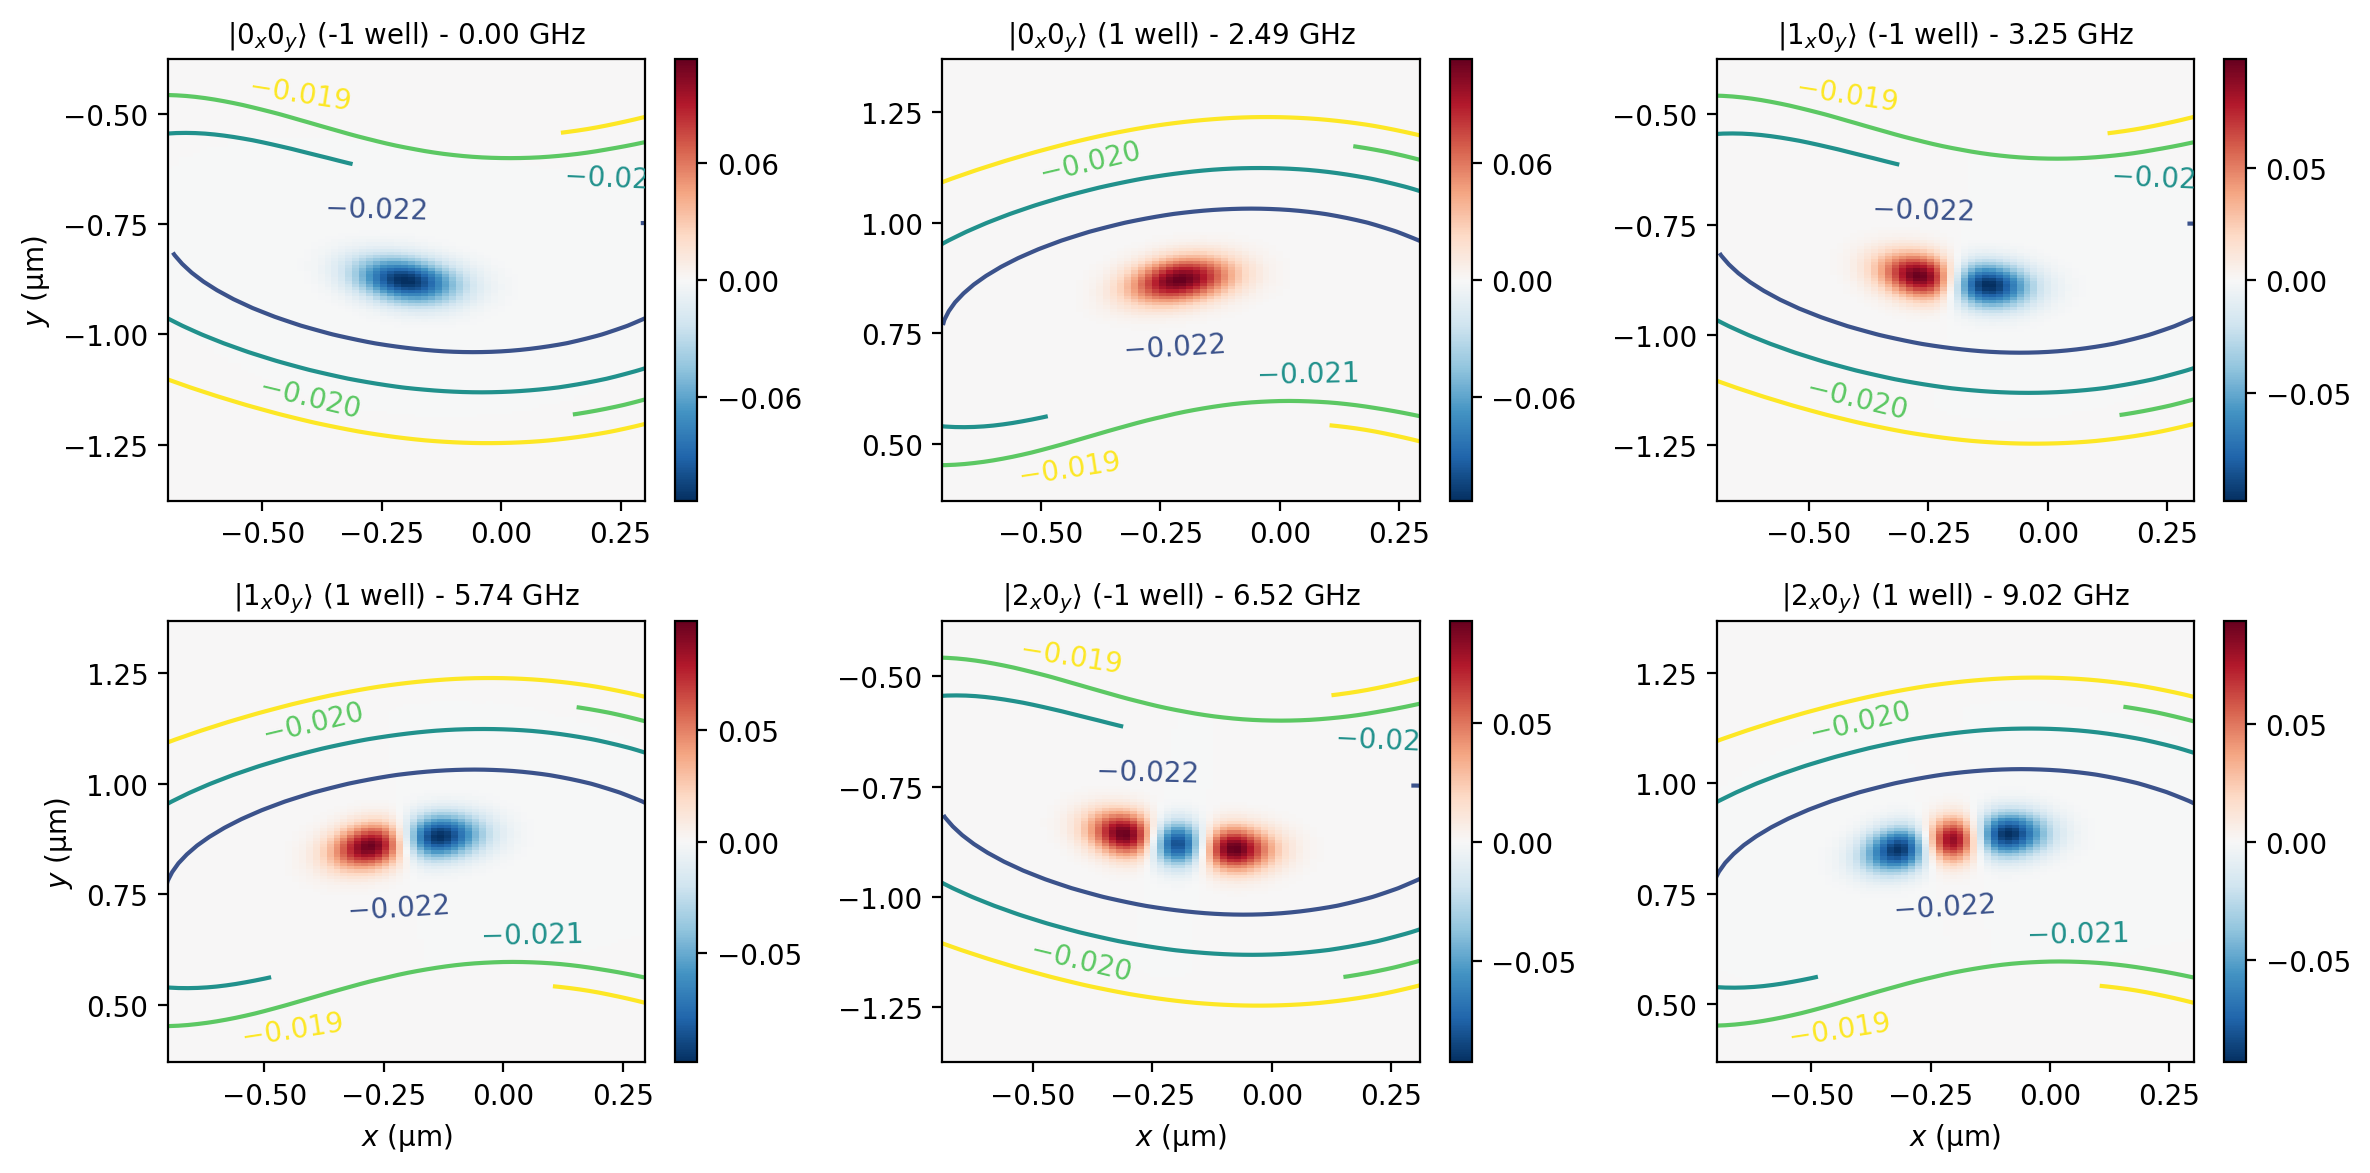

In [8]:
 #Returns the frequencies of the first N=6 eigenmodes for a single electron trapped in a potential. 
single_electron_frequencies = qa.get_quantum_spectrum(coor=(0, 0), dxdy=(2.9, 2.9), plot_wavefunctions=True, axes_zoom=1, n_x=201, n_y=201)
# here the energy splitting between first and excited is higher than with the same script on box because the S. equation is solved on a larger interval

## How many electrons can be trapped ?

402.7985860938143
There are 1 electrons in the dot.
Electron positions: x_min=-5.00e-06, x_max=1.98e-06, y_min=-4.00e-06, y_max=3.98e-06


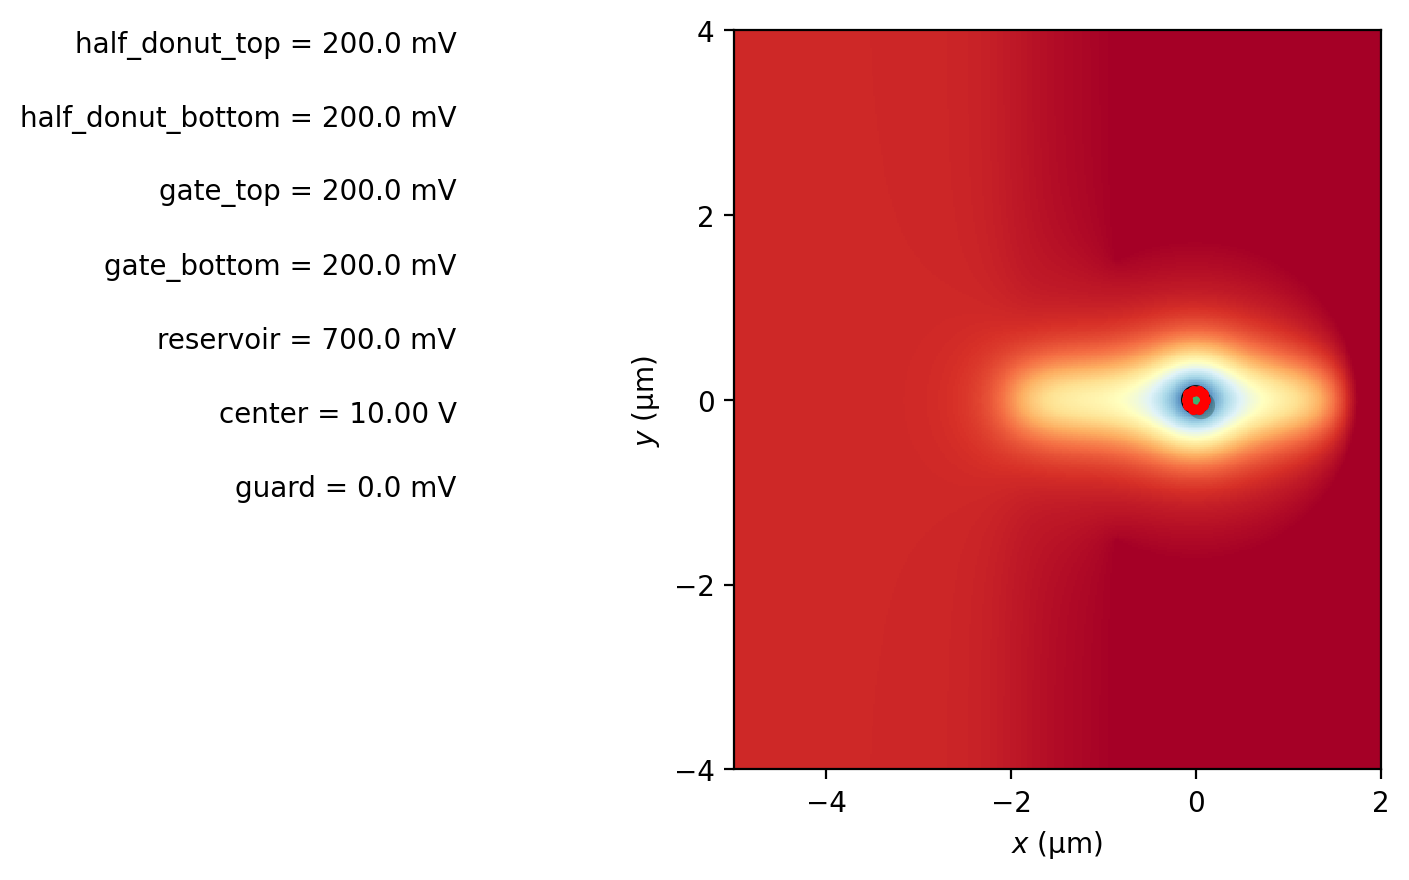

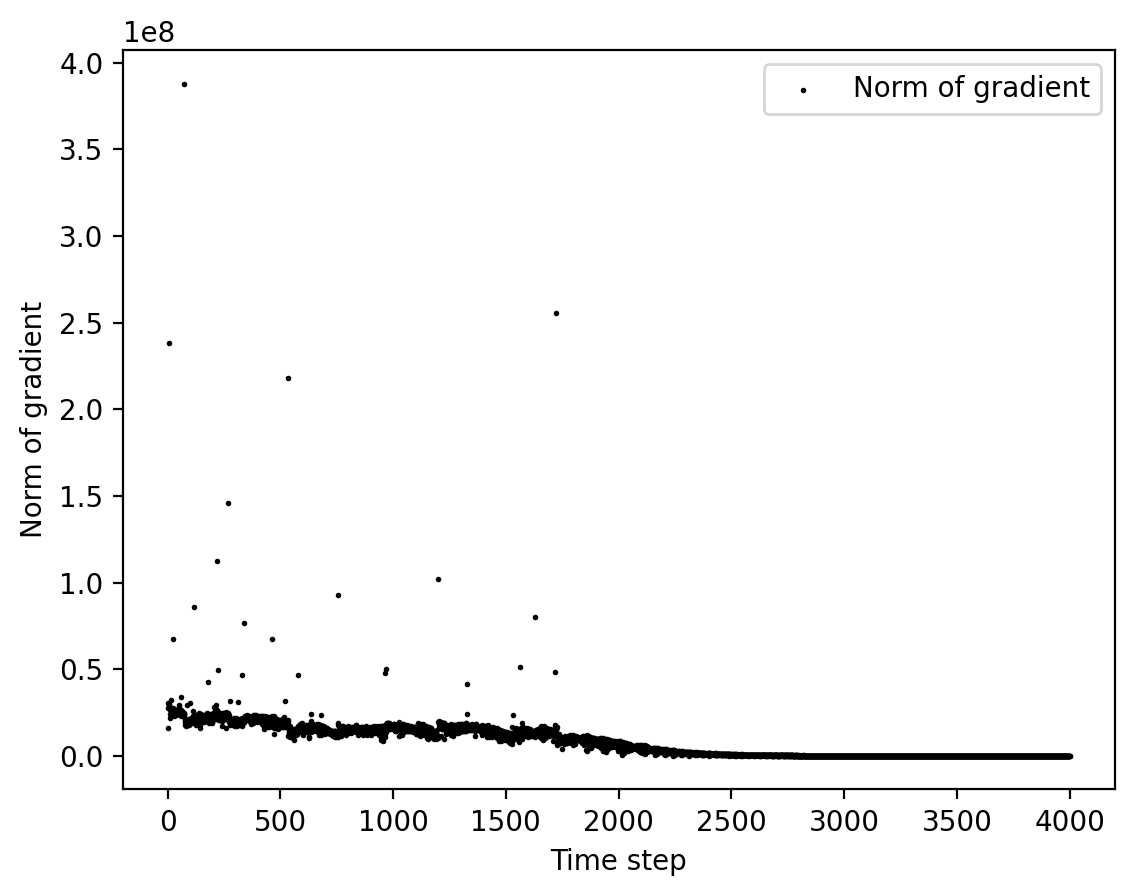

In [53]:
x_min= np.min(trap.dot['xlist'])*1e-6
x_max= np.max(trap.dot['xlist'])*1e-6
y_min= np.min(trap.dot['ylist'])*1e-6
y_max= np.max(trap.dot['ylist'])*1e-6

#configuration test 1
# voltages = {
#     'half_donut_top':0.5,
#     'half_donut_bottom':0.5,
#     'gate_top':0.2,
#     'gate_bottom':0.2,
#     'reservoir':0.7,
#     'center':0.6,
#     'guard':0.000,
# }
  
voltages = {
    'half_donut_top':0.2,
    'half_donut_bottom':0.2,
    'gate_top':0.2,
    'gate_bottom':0.2,
    'reservoir':0.7,
    'center':10,
    'guard':0.000,
}




plot_initial_condition = True
convergence_method = 'Physical gradient descent'  # 'Physical gradient descent' or 'L-BFGS-B'
Nmax = 5
energies = np.zeros(Nmax-1)
norm_grad = []
for N in [10]:
    f = FullModel(trap.dot, voltages)
    f.remove_unbound_electrons = False

    initial_condition = f.generate_initial_condition(N, center=[0,0],radius=0.1e-6)
    init_x, init_y = r2xy(initial_condition)

    if convergence_method == 'L-BFGS-B':
        
        f.trap_annealing_steps = [0.5] *30
        res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition, verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
        equilibrium_positions= res['x']



            
    elif convergence_method == 'Physical gradient descent':
        n_timesteps = 4000
        dt = 1e-13 
        gamma = -0.01 * me / dt # This is the damping parameter. 
        r = np.zeros((2 * N, n_timesteps+2))

        r[:, 0] = initial_condition
        r[:, 1] = initial_condition

        for j in range(2, n_timesteps+2):
            # sets the electrons that are outside the potential to the boundary values
            # r[::2, j-1] = np.clip(r[::2, j-1], x_min, x_max)
            # r[1::2, j-1] = np.clip(r[1::2, j-1], y_min, y_max)

            prefactor = 1 / (me / dt ** 2 - gamma / dt)
            F = - qe * f.grad_total(r[:, j-1])
            norm_grad.append(np.linalg.norm(f.grad_total(r[:, j-1])))
            r_next = prefactor * (F + r[:, j-1] * (2 * me / dt ** 2 - gamma / dt) - r[:, j-2] * me / dt ** 2)
            
            x_next = r_next[::2]
            y_next = r_next[1::2]

            inside = np.logical_and.reduce((
            x_next >= x_min, x_next <= x_max,
            y_next >= y_min, y_next <= y_max
        ))
            
            r_filtered = np.empty((2 * np.sum(inside), j + 1))

            for step in range(j):
                x = r[::2, step][inside]
                y = r[1::2, step][inside]
                r_filtered[::2, step] = x
                r_filtered[1::2, step] = y

            # add the new column
            r_filtered[::2, j] = x_next[inside]
            r_filtered[1::2, j] = y_next[inside]

            # Update the remaining electrons
            r = r_filtered


        equilibrium_positions = r[:, -1]
        print(np.linalg.norm(f.grad_total(equilibrium_positions)))

    final_x, final_y = r2xy(equilibrium_positions)
    number_electron=f.count_electrons_in_dot(equilibrium_positions, trap_bounds_x=(-10*1e-6, 2e-6), trap_bounds_y=(-2e-6, 2e-6))
    print(f'There are {number_electron} electrons in the dot.')

    # plot the final electron positions
    fig, ax =plt.subplots()
    f.plot_potential_energy(coor=[0, 0], dxdy=(10, 8), ax=ax)
    res = {'x': equilibrium_positions}
    f.plot_electron_positions(res)
    ax.set_xlim(-5, 2)

    if plot_initial_condition:
        plt.plot(init_x*1e6, init_y*1e6, 'or', ms=3)
    # f.plot_convergence()
    # print(res['status'])
    # energies[N-1] = res['fun']

    # Test if some electrons are outside the potential grid
    x=r[::2] 
    y=r[1::2]

    print(f"Electron positions: x_min={x_min:.2e}, x_max={x_max:.2e}, y_min={y_min:.2e}, y_max={y_max:.2e}")
    if np.any(x < x_min) or np.any(x > x_max) or np.any(y < y_min) or np.any(y > y_max):
        print("Electron outside potential grid!")

    fig, ax = plt.subplots()
    ax.scatter(range(2, n_timesteps+2), norm_grad, s=1, c='k', label='Norm of gradient')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Norm of gradient')
    ax.legend()
    # ax.set_xlim(40000, 50000)
    # ax.set_ylim(0,10000)


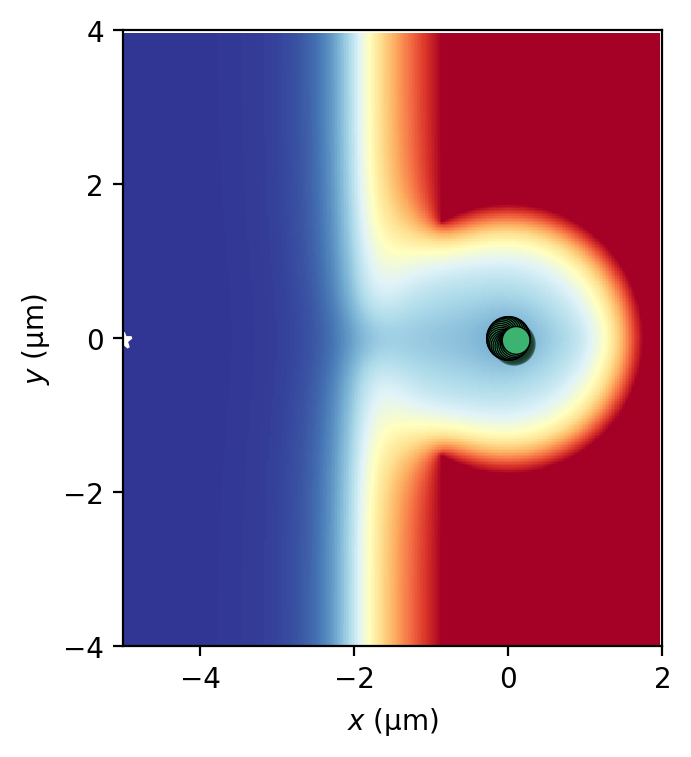

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
f.plot_potential_energy(ax=ax, dxdy=(10, 8), print_voltages=False, plot_contours=False)
pts_data = ax.plot(final_x*1e6, final_y*1e6, 'ok', mfc='mediumseagreen', mew=0.5, ms=10, path_effects=[pe.SimplePatchShadow(), pe.Normal()])
# Only things in the update function will get updated.
def update(frame):
    rx, ry = r2xy(r[:, frame])
    # Update the electron positions (green dots)    
    pts_data[0].set_xdata(rx * 1e6)
    pts_data[0].set_ydata(ry * 1e6)

    return pts_data, 

# The interval is in milliseconds 
ax.set_xlim(-5, 2)
anim = animation.FuncAnimation(fig=fig, func=update, frames=np.arange(2, n_timesteps+2, 25), interval=30, repeat=True)


In [9]:
f.show_animation(anim)

## Motional states

To solve the motional states, we must define the electric fields that could couple to the resonator mode. There are 2 options, either the `halfdonut` or the `center` electrode.

In [136]:
Vrms = 140e-9
f0 = 0.8e9

Z = 2 / 1.055e-34 * (Vrms / (2 * np.pi * f0)) ** 2

voltages = {
    'half_donut_top':0.005,
    'half_donut_bottom':0.005,
    'gate_top':0.001,
    'gate_bottom':0.001,
    'reservoir':0.007,
    'center':0.005,
    'guard':0.000,
}



  
options = { "include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : np.inf, # Typically helium thickness.
           "potential_smoothing" : 1e-5, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : False, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : None, # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.1] * 10, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.1e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.1e-6} # Maximum y-displacement of solved electron positions during annealing.

#addded
resonator_dict = {"f0" : f0, # Resonance frequency for the resonator (only used for solving motional frequencies)
                  "Z0" : Z} # Resonator impedance (only used for solving motional frequencies)

1839.192026614803


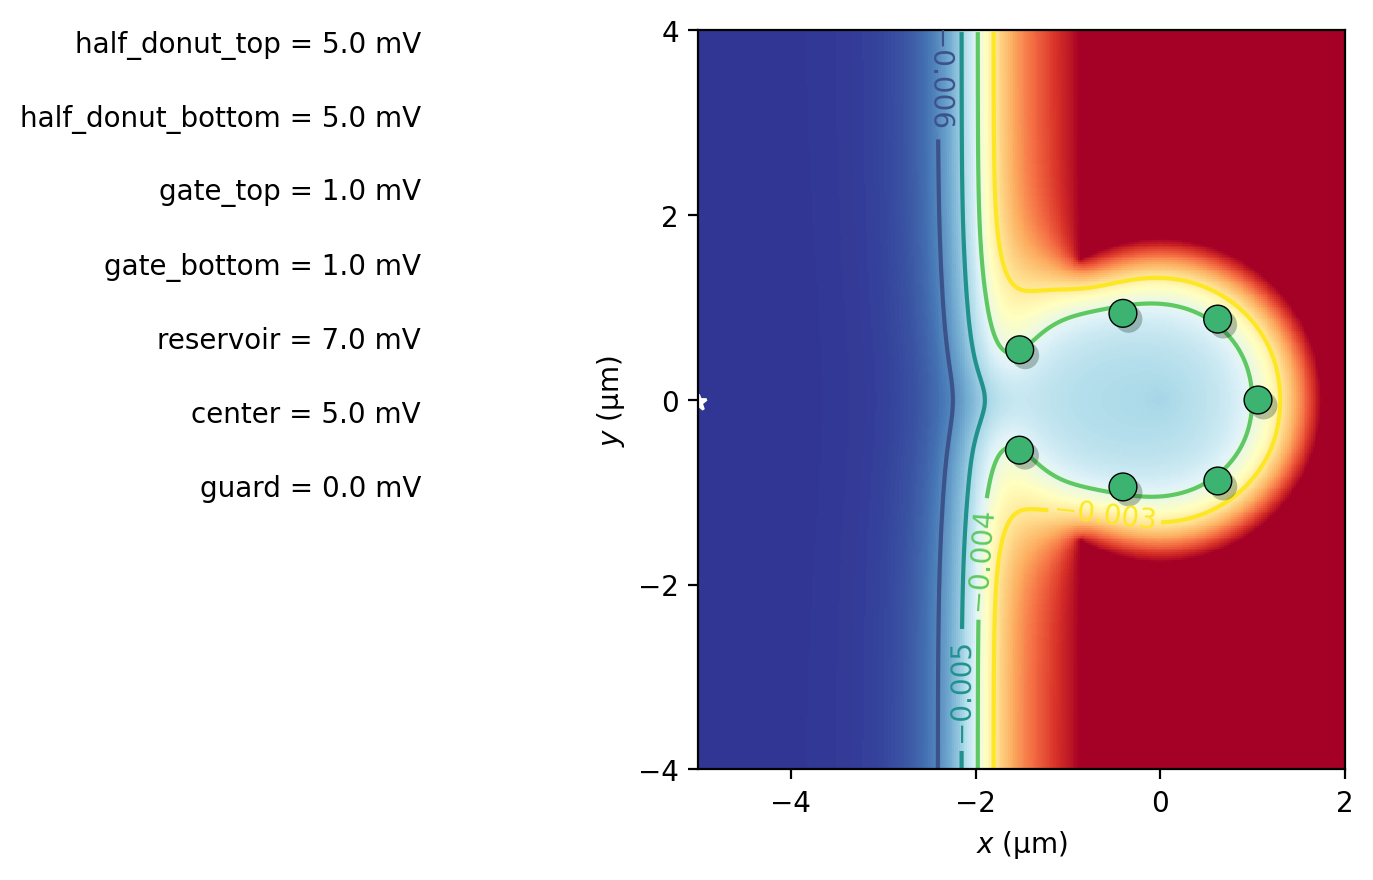

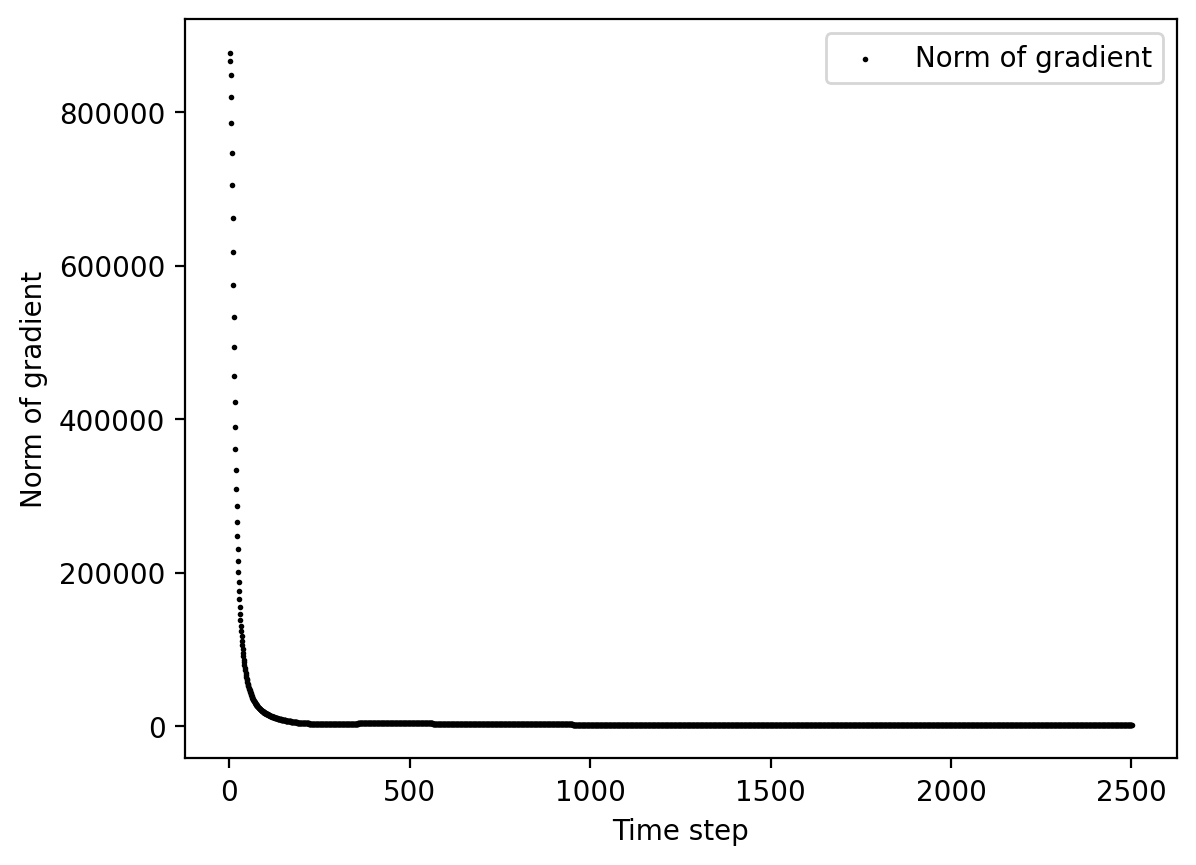

In [137]:
N = 7

f = FullModel(trap.dot, voltages, **options)
f.remove_unbound_electrons = False
f.trap_annealing_steps = [1] * 25

# connect the RF resonator to the center or the half donut electrode
f.set_rf_interpolator(rf_electrode_labels=['guard'])



# initial_condition=xy2r(np.array([0,-4.5*1e-6]), np.array([0,0]))
initial_condition = f.generate_initial_condition(N, center=[0,0], radius=0.1e-6)
init_x, init_y = r2xy(initial_condition)

# res = f.get_electron_positions(n_electrons=N, electron_initial_positions=None, verbose=False)\
n_timesteps = 2500
dt = 1e-13
gamma = -0.01 * me / dt # This is the damping parameter. 
r = np.zeros((2 * N, n_timesteps+2))

r[:, 0] = initial_condition
r[:, 1] = initial_condition
norm_grad=[]


for j in range(2, n_timesteps+2):
    # sets the electrons that are outside the potential to the boundary values
    # r[::2, j-1] = np.clip(r[::2, j-1], x_min, x_max)
    # r[1::2, j-1] = np.clip(r[1::2, j-1], y_min, y_max)

    prefactor = 1 / (me / dt ** 2 - gamma / dt)
    F = - qe * f.grad_total(r[:, j-1])
    norm_grad.append(np.linalg.norm(f.grad_total(r[:, j-1])))
    r_next = prefactor * (F + r[:, j-1] * (2 * me / dt ** 2 - gamma / dt) - r[:, j-2] * me / dt ** 2)
    
    x_next = r_next[::2]
    y_next = r_next[1::2]

    inside = np.logical_and.reduce((
    x_next >= x_min, x_next <= x_max,
    y_next >= y_min, y_next <= y_max
))
    
    r_filtered = np.empty((2 * np.sum(inside), j + 1))

    for step in range(j):
        x = r[::2, step][inside]
        y = r[1::2, step][inside]
        r_filtered[::2, step] = x
        r_filtered[1::2, step] = y

    # add the new column
    r_filtered[::2, j] = x_next[inside]
    r_filtered[1::2, j] = y_next[inside]

    # Update the remaining electrons
    r = r_filtered

equilibrium_positions = r[:, -1]
print(np.linalg.norm(f.grad_total(equilibrium_positions)))
final_x, final_y = r2xy(equilibrium_positions)

fig, ax = plt.subplots()
f.plot_potential_energy(ax=ax, coor=[0,0], dxdy=(10, 8))
ax.set_xlim(-5, 2)
res = {'x': equilibrium_positions}
f.plot_electron_positions(res)

fig, ax = plt.subplots()
ax.scatter(range(2, n_timesteps+2), norm_grad, s=1, c='k', label='Norm of gradient')
ax.set_xlabel('Time step')
ax.set_ylabel('Norm of gradient')
ax.legend()

In [71]:
f.count_electrons_in_dot(res['x'], trap_bounds_x=(-5e-6, 2e-6),
                         trap_bounds_y=(-4e-6, 4e-6))



np.int64(3)

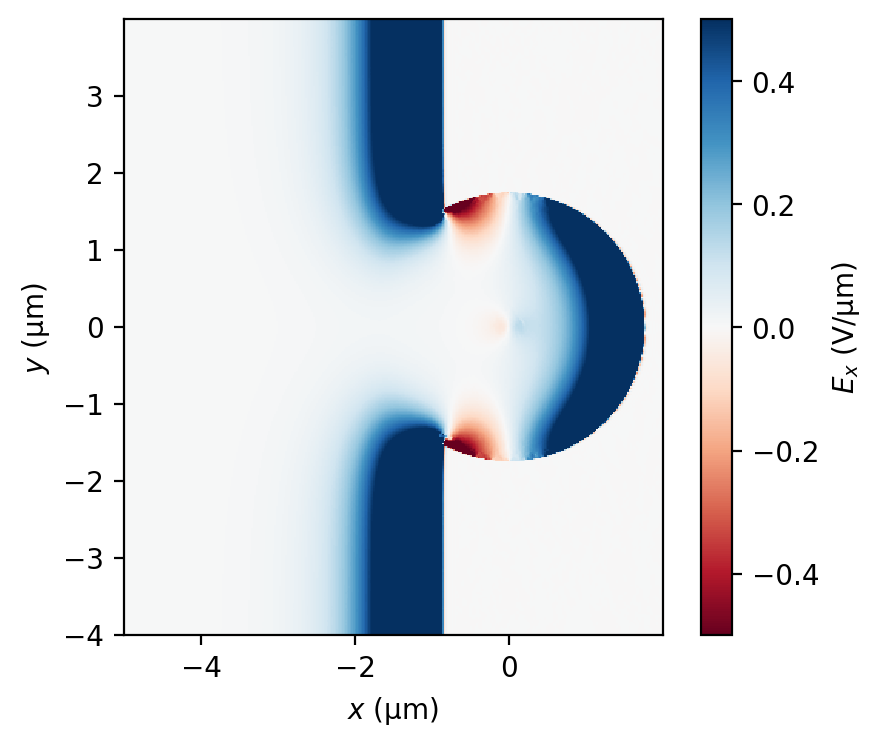

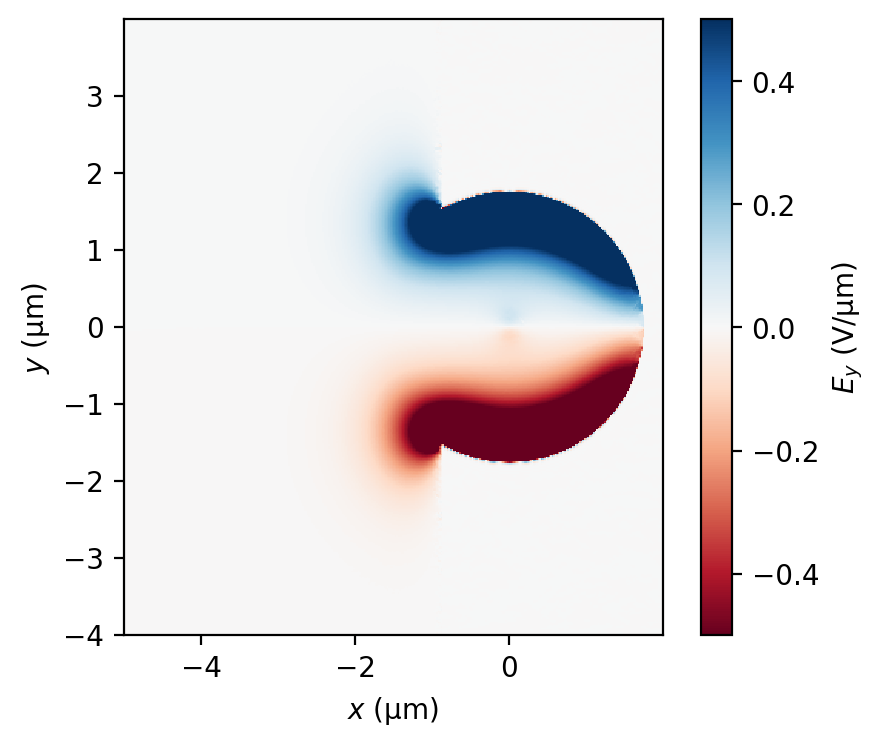

In [72]:
X, Y = np.meshgrid(trap.dot['xlist'] * 1e-6, trap.dot['ylist'] * 1e-6)

Ex = f.Ex(X, Y)
Ey = f.Ey(X, Y)

fig = plt.figure(figsize=(5, 4.))
plt.pcolormesh(X * 1e6, Y * 1e6, Ex / 1e6, cmap=plt.cm.RdBu, vmax=0.5, vmin=-0.5)
cbar = plt.colorbar()
cbar.ax.set_ylabel(f"$E_x$ (V/{chr(956)}m)")
plt.xlabel(rf"$x$ ({chr(956)}m)")
plt.ylabel(rf"$y$ ({chr(956)}m)")
plt.gca().set_aspect('equal')

fig = plt.figure(figsize=(5, 4.))
plt.pcolormesh(X * 1e6, Y * 1e6, Ey / 1e6, cmap=plt.cm.RdBu, vmax=0.5, vmin=-0.5)
cbar = plt.colorbar()
cbar.ax.set_ylabel(f"$E_y$ (V/{chr(956)}m)")
plt.xlabel(rf"$x$ ({chr(956)}m)")
plt.ylabel(rf"$y$ ({chr(956)}m)")
plt.gca().set_aspect('equal')

In [133]:
# solves the equations of motion  
K, M = f.setup_eom(res['x'], resonator_dict=resonator_dict)
# added: resonator_dict=resonator_dict
eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)

In [134]:
eigenfrequencies

array([7.99999257e+08, 6.87050875e+08, 4.92243624e+09, 3.12953282e+09,
       5.55389281e+09, 3.67251107e+09, 6.90087920e+09,            nan,
       1.97013434e+09, 3.82944219e+09, 4.48589846e+09,            nan,
       7.02649586e+09, 2.84149337e+09, 3.47749845e+09])

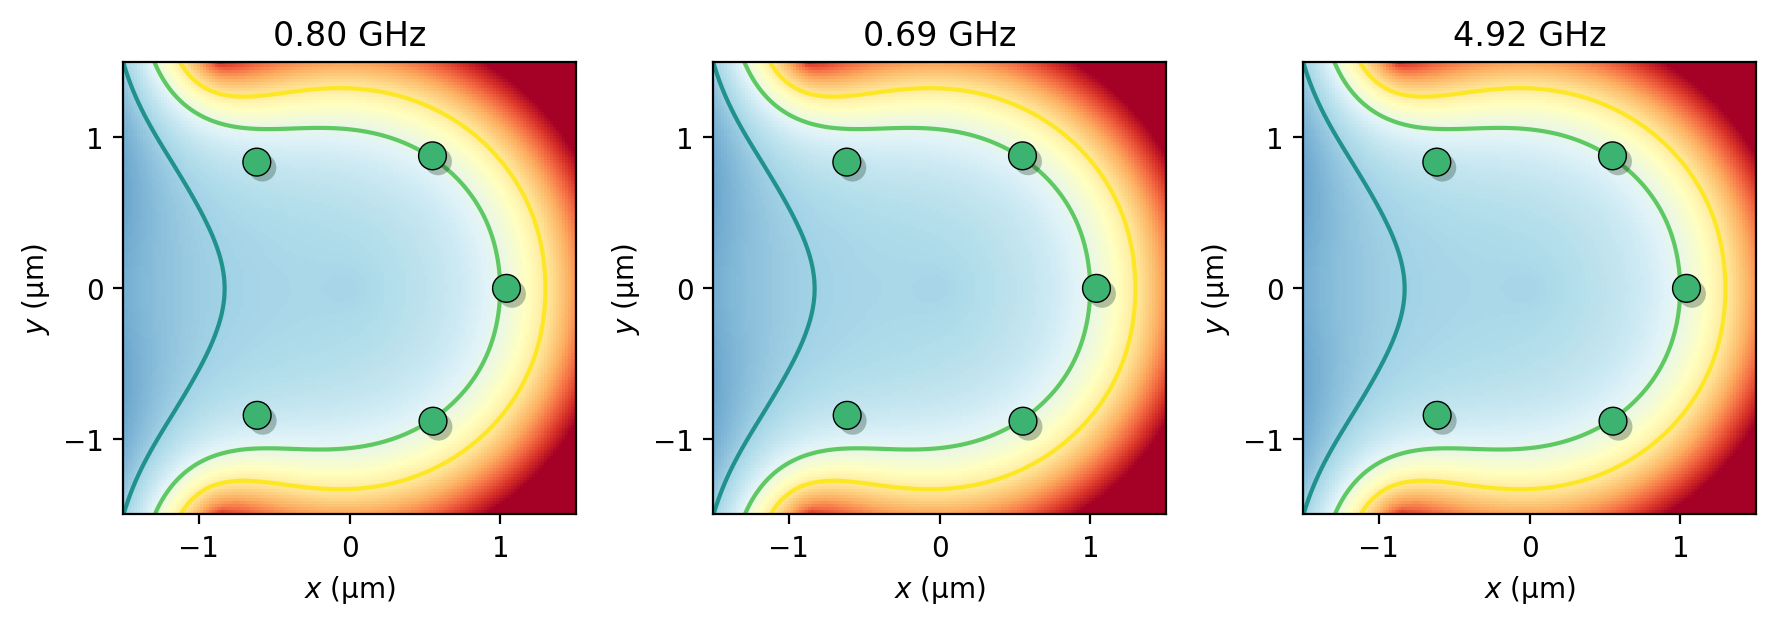

In [135]:
fig, ax = plt.subplots(1, 3, figsize=(3 * 3., 4.))

for k in range(3):
    f.plot_potential_energy(ax=ax[k], coor=[0, 0], dxdy=(3, 3), print_voltages=False)
    ax[k].set_title(f"{eigenfrequencies[k]/1e9:.2f} GHz")
    # f.plot_electron_positions(res)

    # f.plot_eigenvector(res['x'], evecs[:, 2], color='white')
    # f.plot_eigenvector(res['x'], evecs[:, 1], color='gray')

fig.tight_layout()
anim = f.animate_eigenvectors(fig, ax, eigenvector_list=evecs.T, electron_positions=res['x'],
                              amplitude=0.25e-6)

In [76]:
f.show_animation(anim)

In [19]:
f.save_animation(anim, filepath="./single_electron_very_small_voltages.gif")

In [20]:
trap.dot.keys()

dict_keys(['center', 'gate_bottom', 'gate_top', 'guard', 'half_donut_bottom', 'half_donut_top', 'reservoir', 'xlist', 'ylist'])

### Voltage sweep 1

In [ ]:
voltages = {
    'half_donut_top':0.003,
    'half_donut_bottom':0.00,
    'gate_top':-0.00,
    'gate_bottom':0.0,
    'reservoir':0.000,
    'center':0.01,
    'guard':0.000,
}
list_of_voltages = []
electron_configurations=[]
sweep_voltages = np.linspace(0, 0.02, 101)
# if you put N electrons, you have 2N+1 eigenfrequencies
eigenfrequencies = np.zeros((len(sweep_voltages), 3))
plot = True

convergence_method='Physical gradient descent' # 'L-BFGS-B' or 'Physical gradient descent'


with alive_progress.alive_bar(len(sweep_voltages), force_tty=True) as bar:
    for k, center in enumerate(sweep_voltages):

        voltages["half_donut_top"] = center
        voltages["half_donut_bottom"] = center
        list_of_voltages.append(voltages.copy())
        N = 1

        f = FullModel(trap.dot, voltages, **options)
        f.remove_unbound_electrons = False
        f.trap_annealing_steps = [0.01] * 10

        f.set_rf_interpolator(rf_electrode_labels=['guard'])

        if k == 0:
            initial_condition = f.generate_initial_condition(N)
        else:
            initial_condition = equilibrium_positions

        if convergence_method == 'L-BFGS-B':

            init_x, init_y = r2xy(initial_condition)
            res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition, verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
            equilibrium_positions= res['x']
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)
            if res['status'] != 0:
                print(f"Error at k={k}, status={res['status']}")
                print(f"Error message: {res['message']}")
                continue

        
        elif convergence_method == 'Physical gradient descent':
            n_timesteps = 50000
            dt = 1e-13 
            gamma = -0.01 * me / dt # This is the damping parameter. 
            r = np.zeros((2 * N, n_timesteps+2))

            r[:, 0] = initial_condition
            r[:, 1] = initial_condition

            for j in range(2, n_timesteps+2):
                prefactor = 1 / (me / dt ** 2 - gamma / dt)
                F = - qe * f.grad_total(r[:, j-1])
                r[:, j] = prefactor * (F + r[:, j-1] * (2 * me / dt ** 2 - gamma / dt) - r[:, j-2] * me / dt ** 2)
                
            equilibrium_positions = r[:, -1]
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)

    


       

        # if plot and not(k%10):
        #     f.plot_potential_energy(coor=[0, 0], dxdy=(3, 3))
        #     f.plot_electron_positions(res)

        # added: resonaotor_dict
    

        K, M = f.setup_eom(equilibrium_positions, resonator_dict=resonator_dict)
        eigenfrequencies[k, :], evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)

        bar()




plt.figure()
plt.plot(sweep_voltages, eigenfrequencies / 1e9)
plt.xlabel(" Voltages (V)")
plt.ylabel("Frequency (GHz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

|█▎⚠︎                                     | (!) 3/101 [3%] in 7.3s (0.39/s)      


KeyboardInterrupt: 

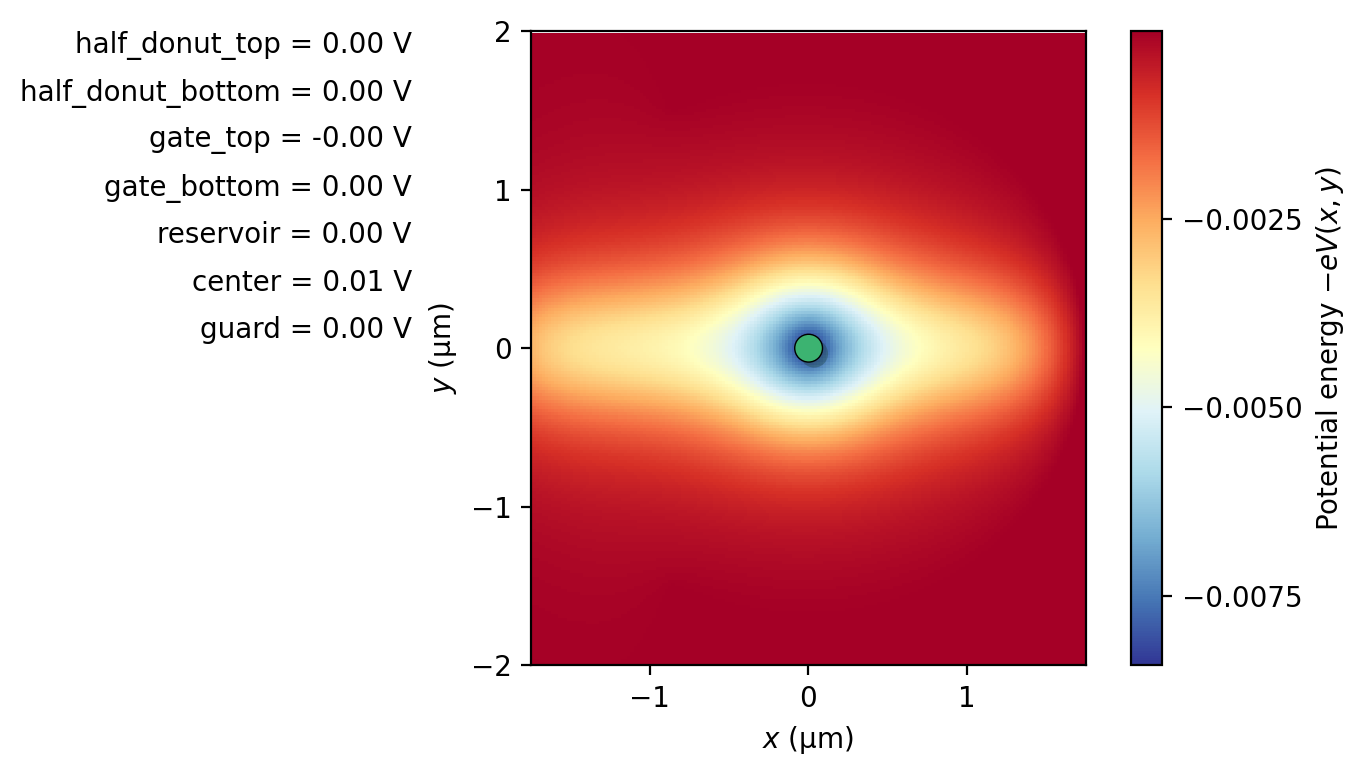

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.))

anim = f.animate_voltage_sweep(fig, ax,  list_of_voltages=list_of_voltages, list_of_electron_positions=electron_configurations,
                            dxdy=(3.5, 4), frame_interval_ms=100 )
f.show_animation(anim)

NameError: name 'sweep_electrode' is not defined

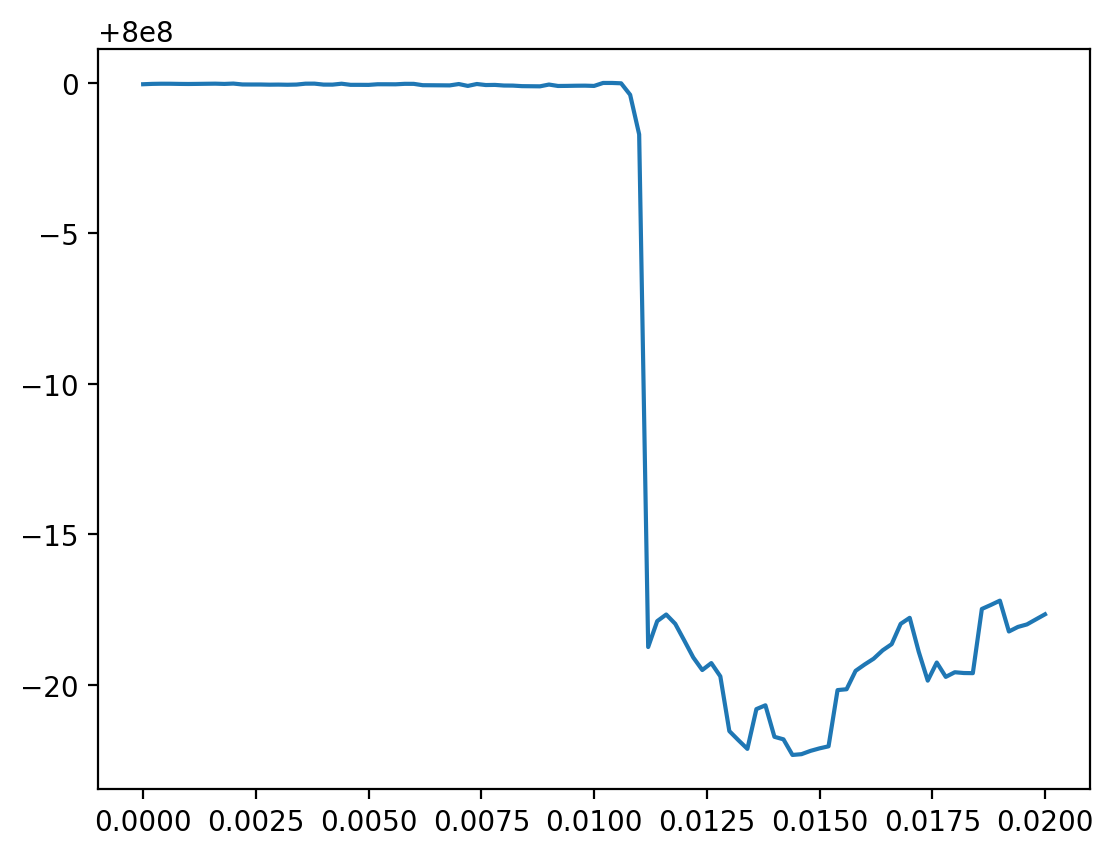

In [23]:
plt.plot(sweep_voltages, eigenfrequencies[:, 0])
plt.xlabel(f"{sweep_electrode.capitalize()} (V)")
plt.ylabel("Resonator frequency (Hz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

### Voltage sweep 2

|████████████████████████████████████████| 101/101 [100%] in 12.1s (8.35/s)     


(0.0012, 0.002)

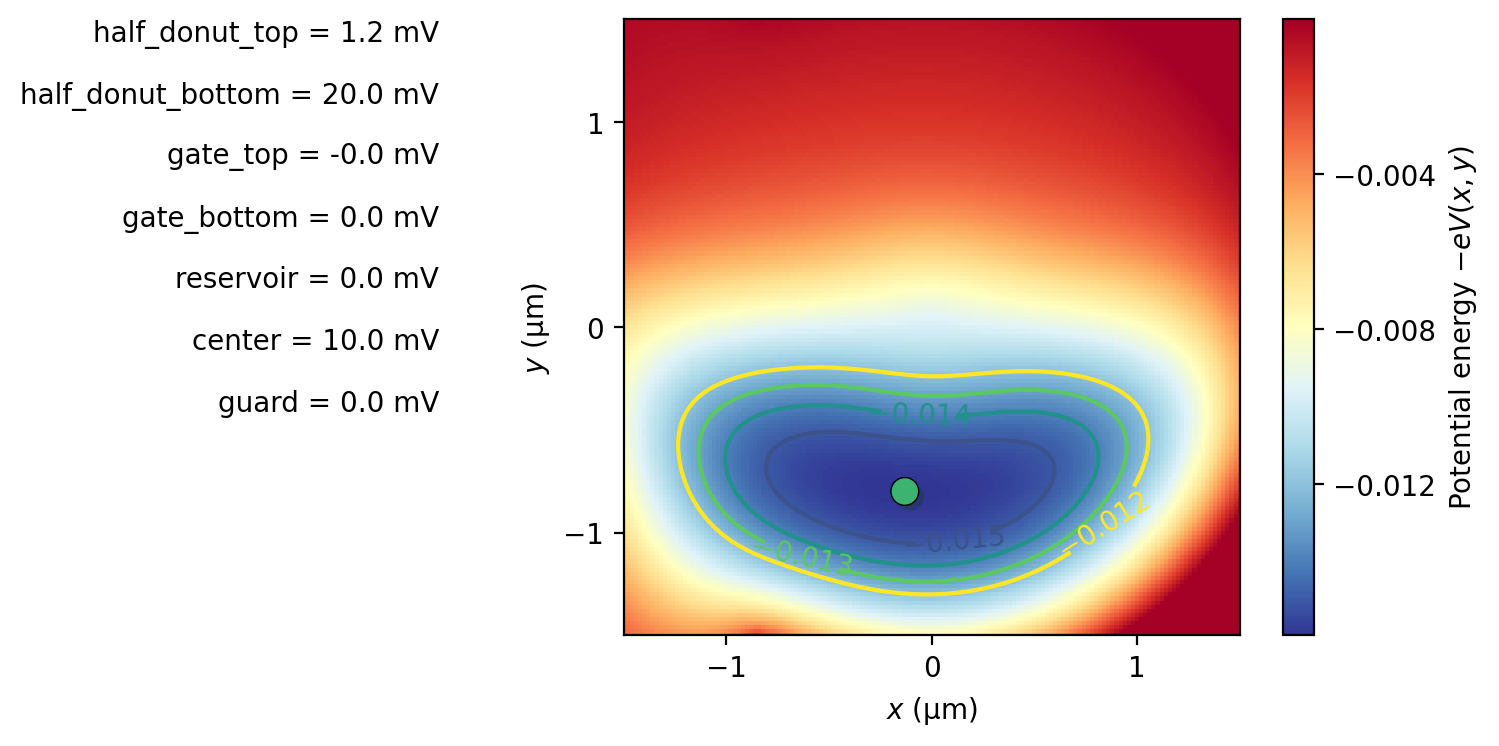

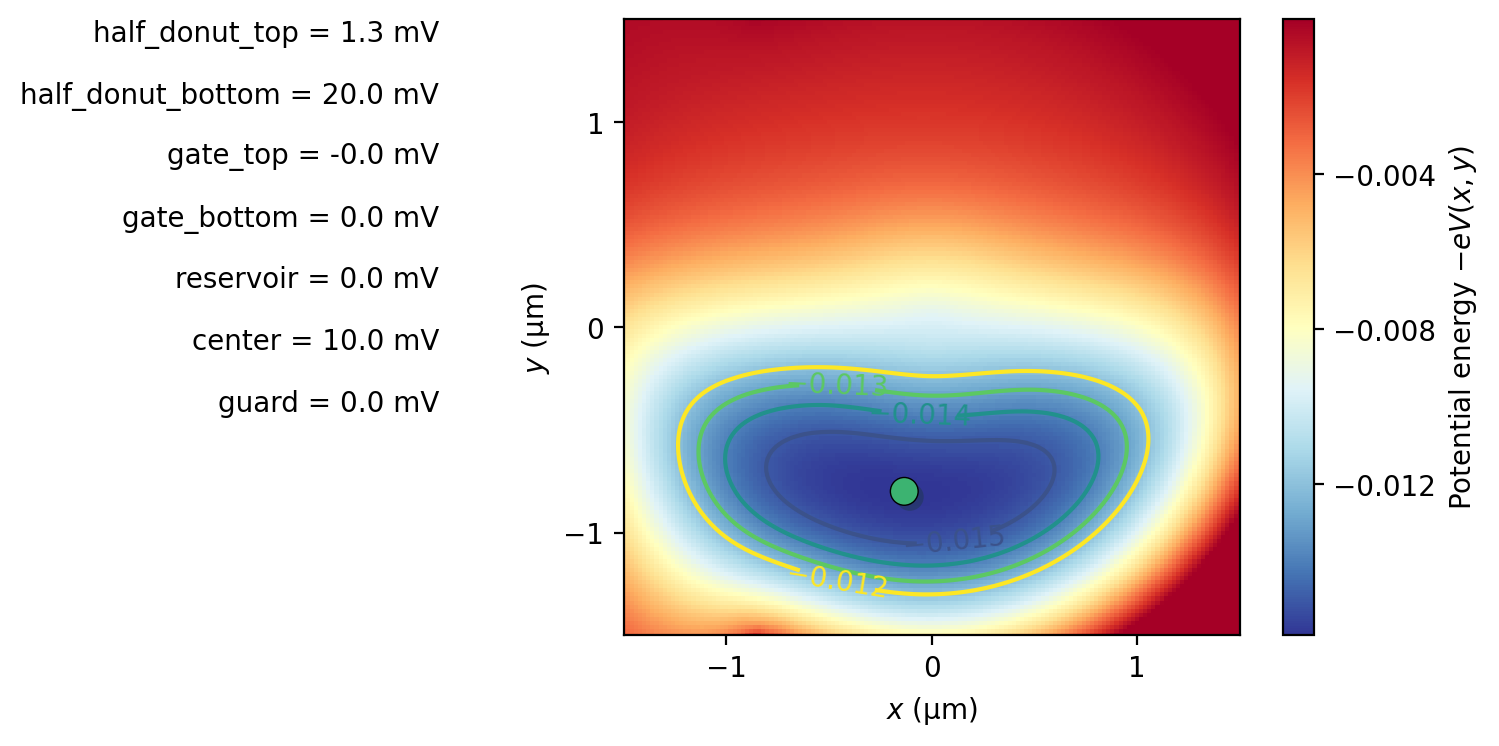

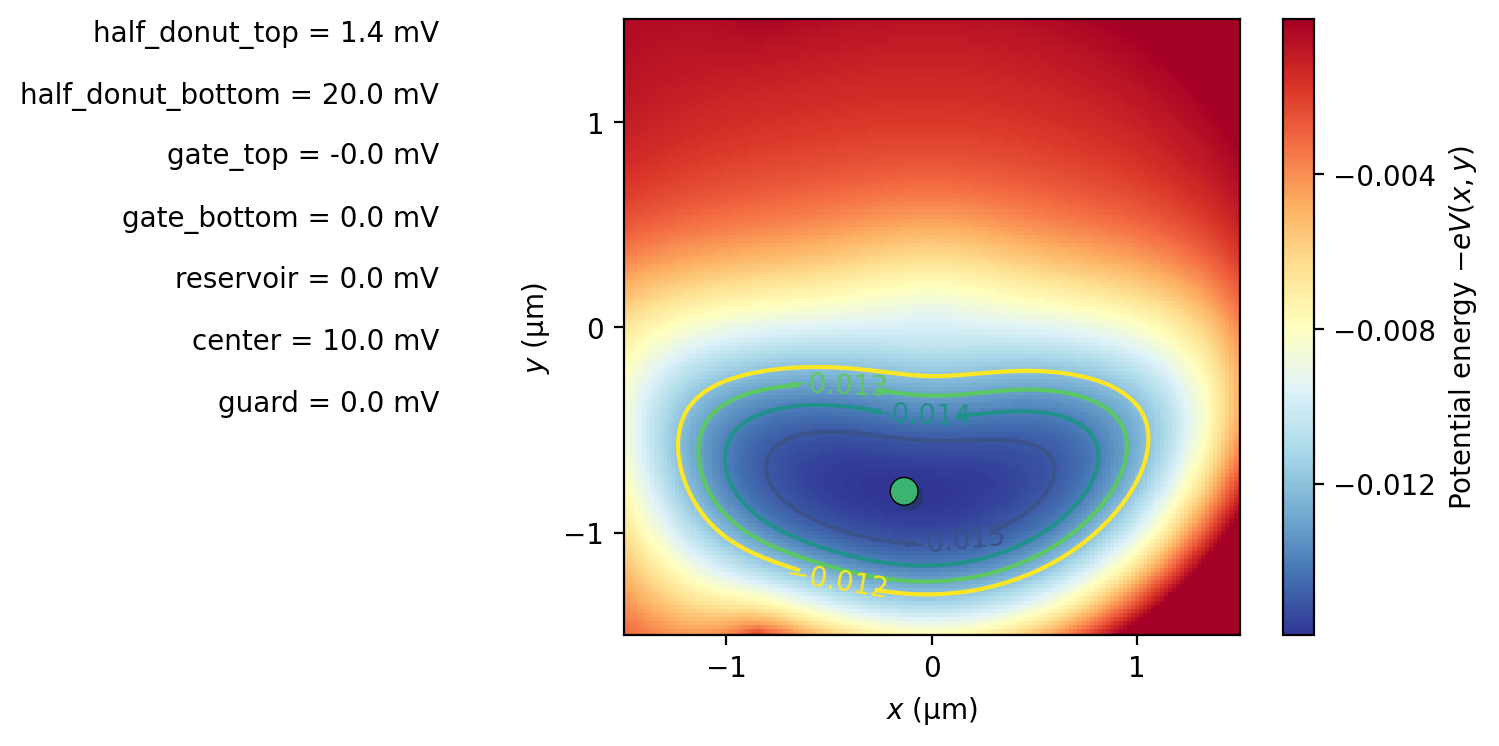

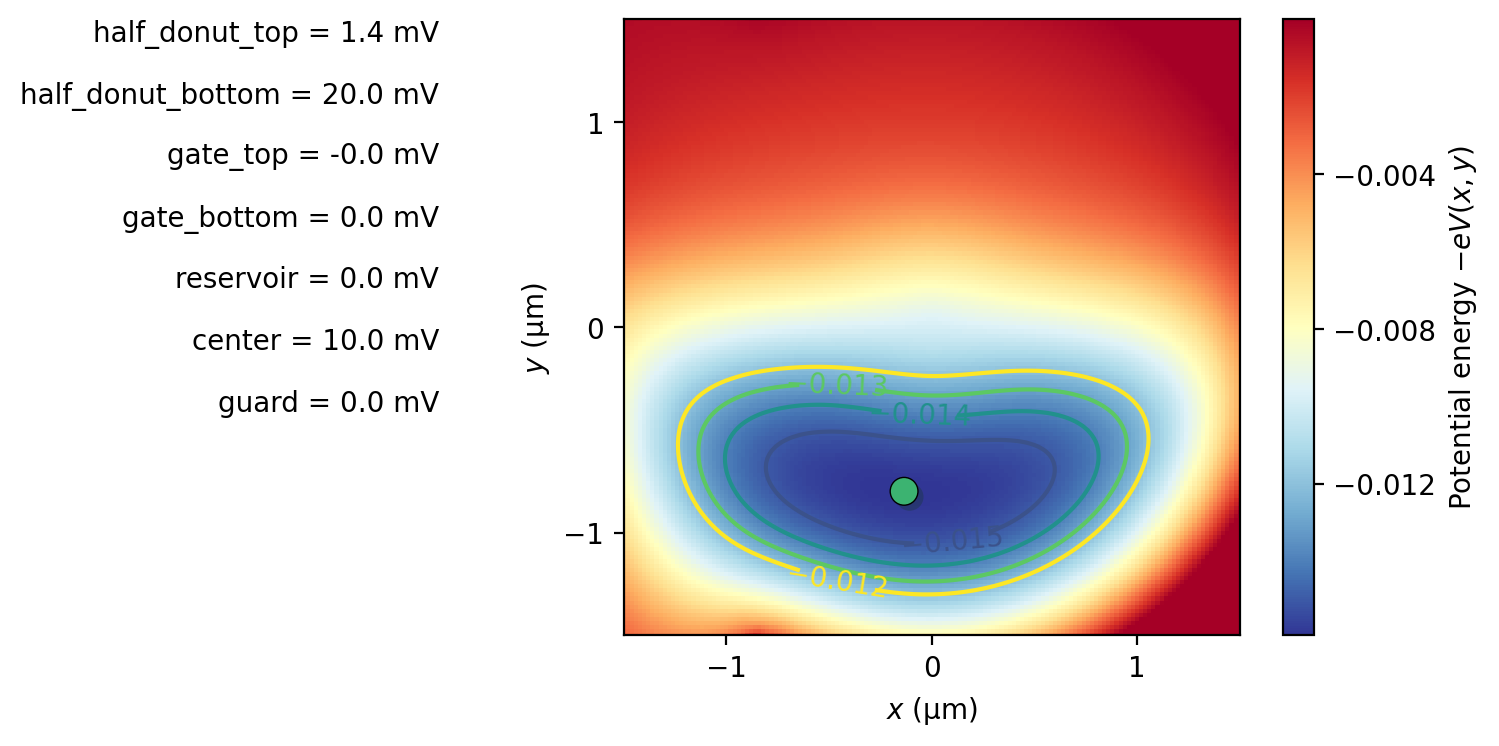

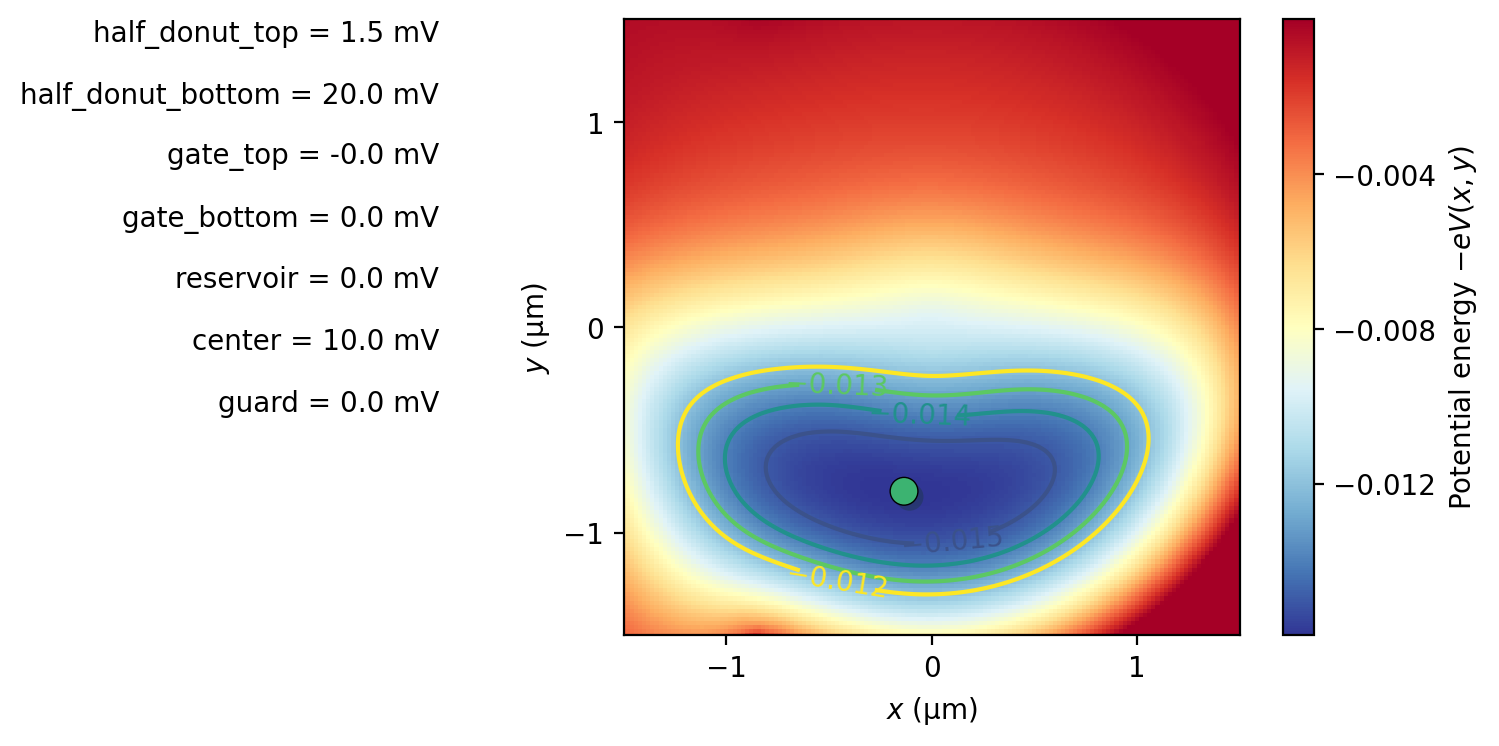

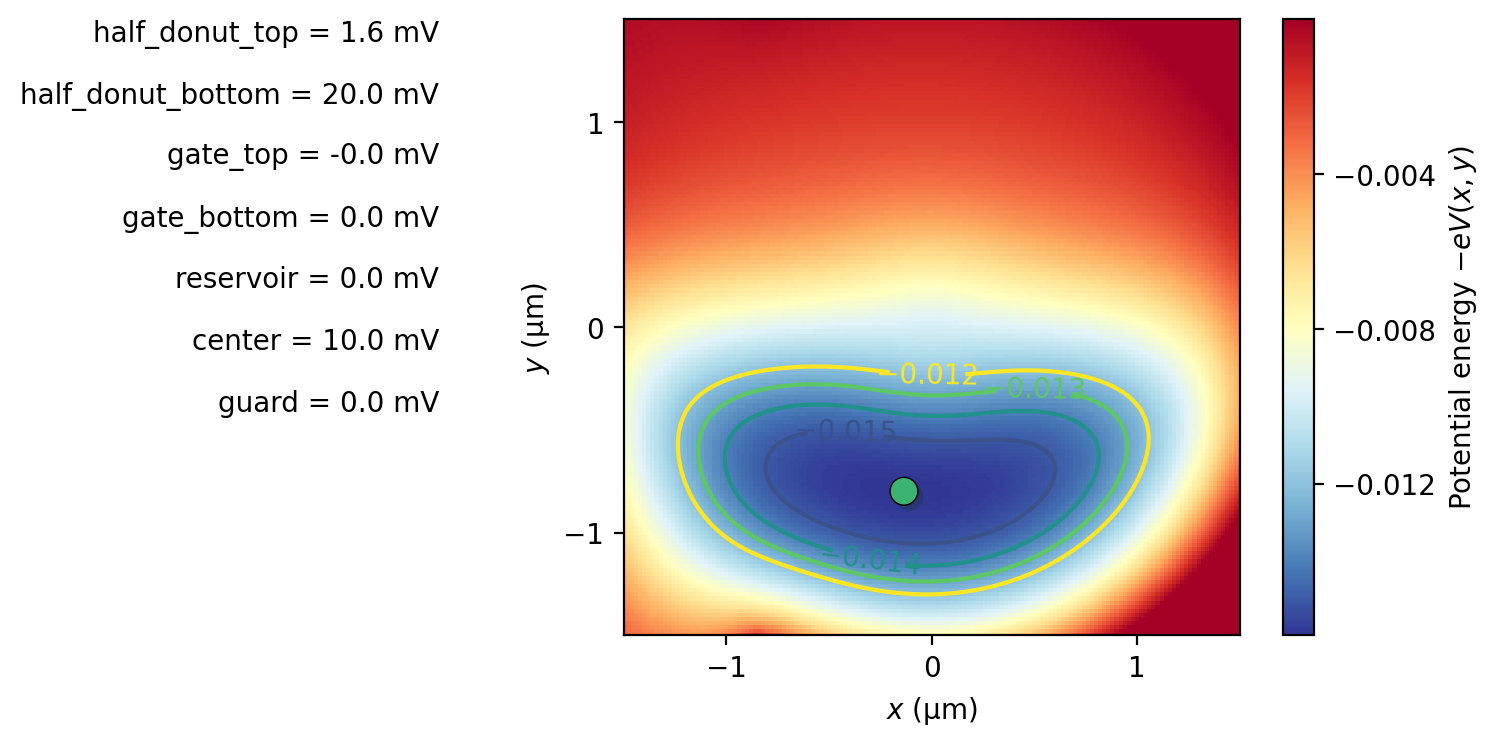

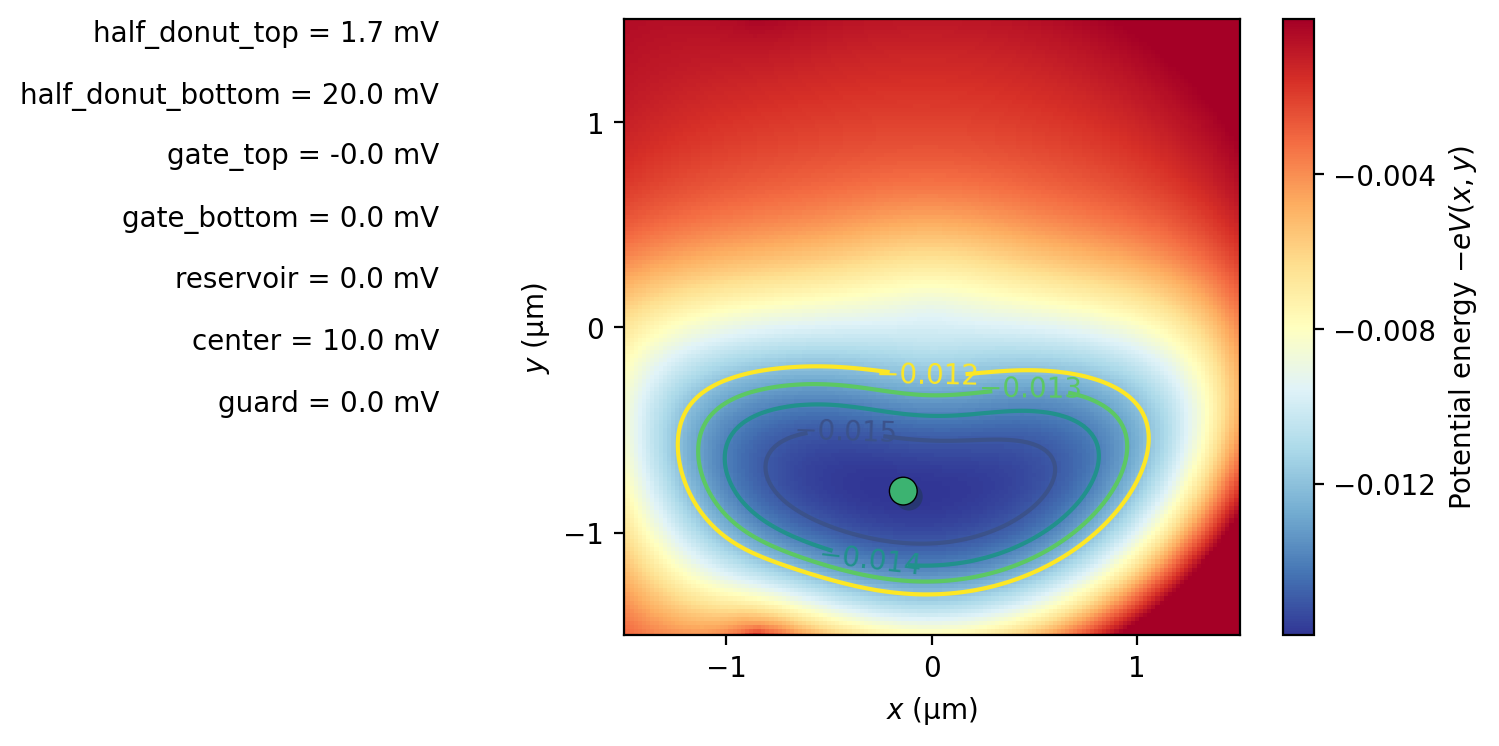

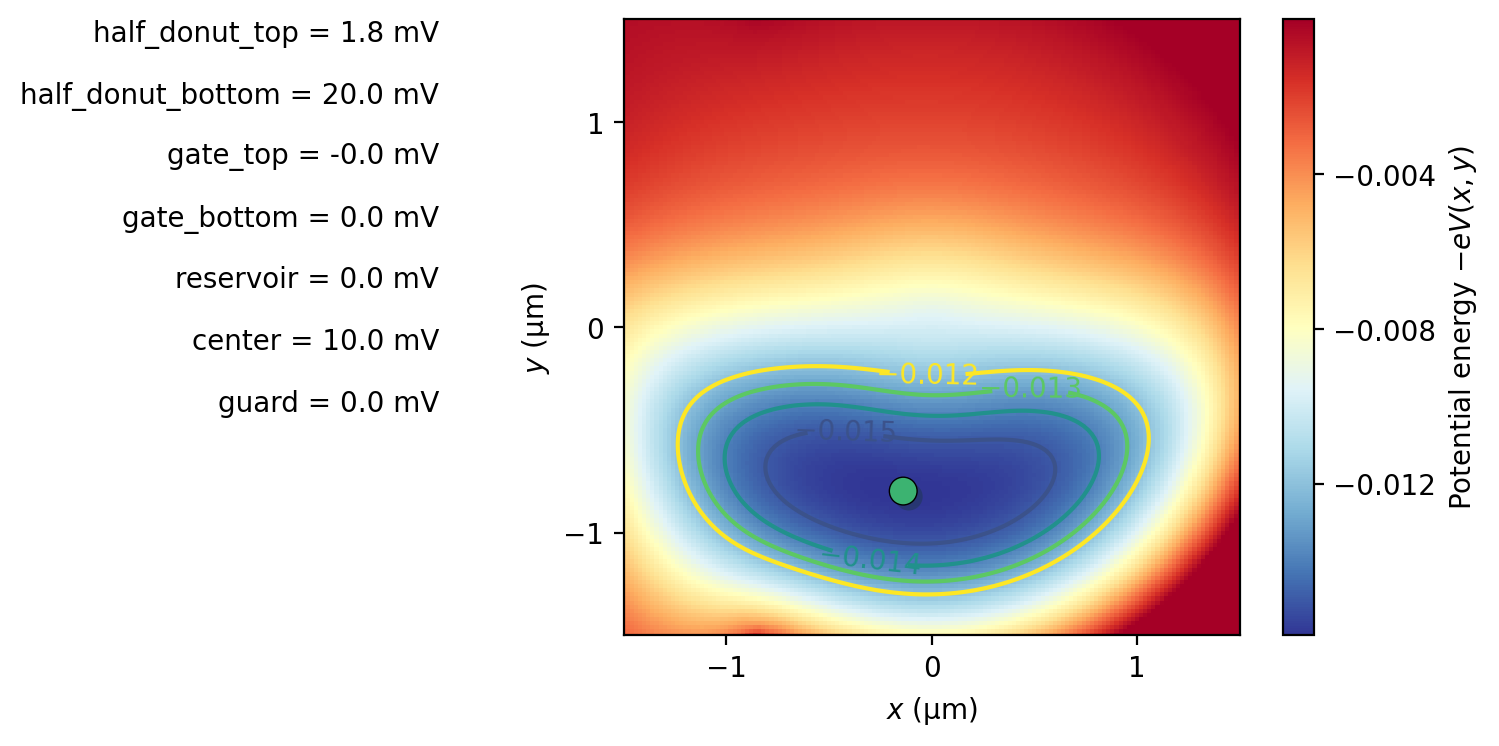

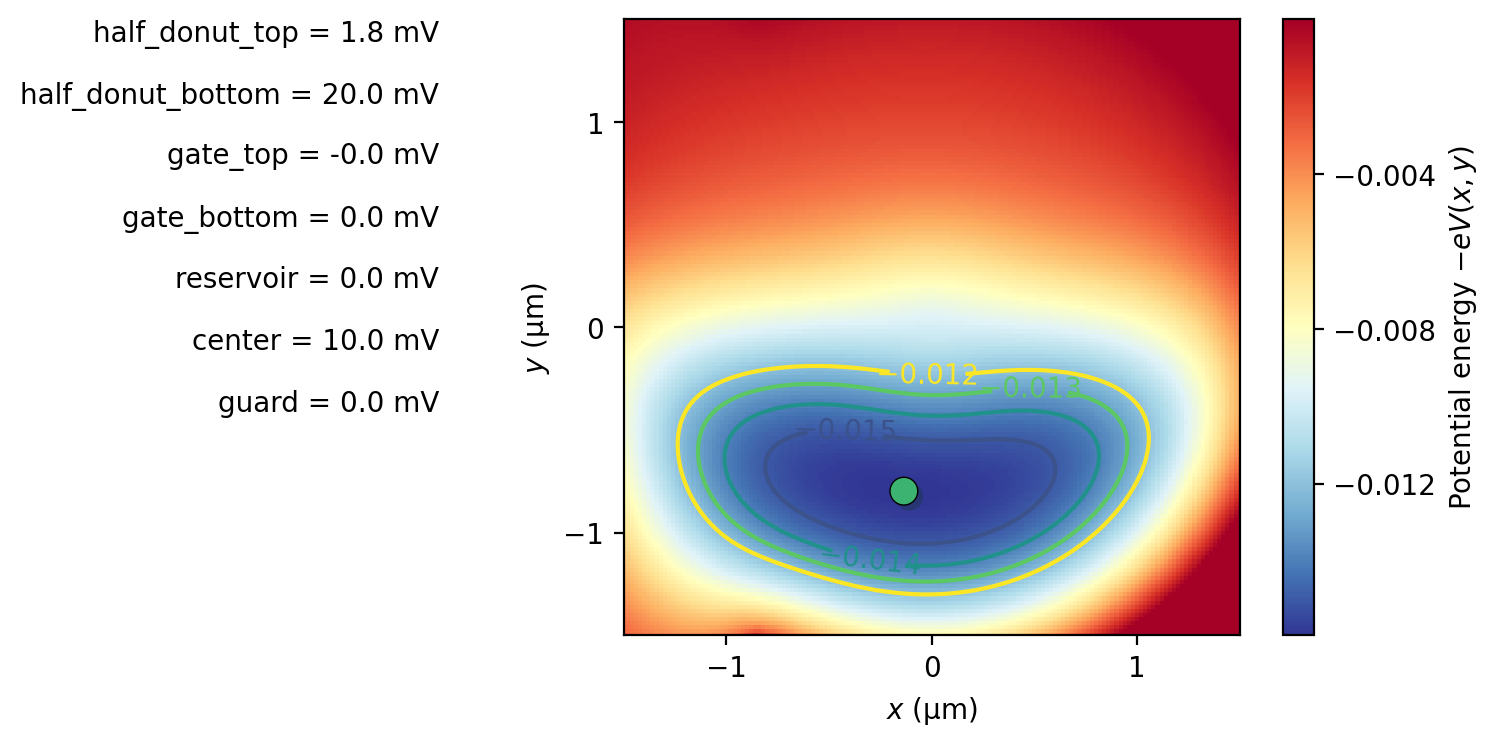

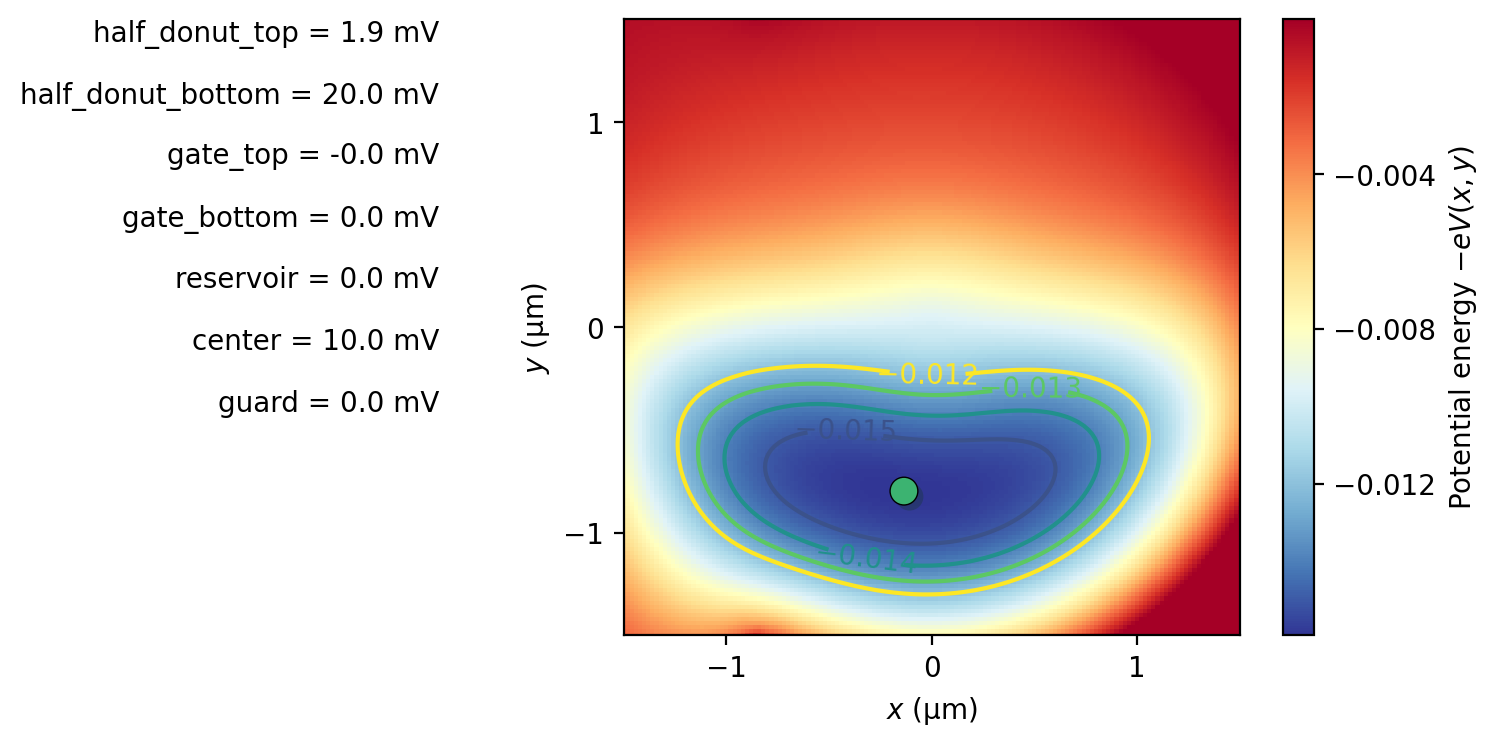

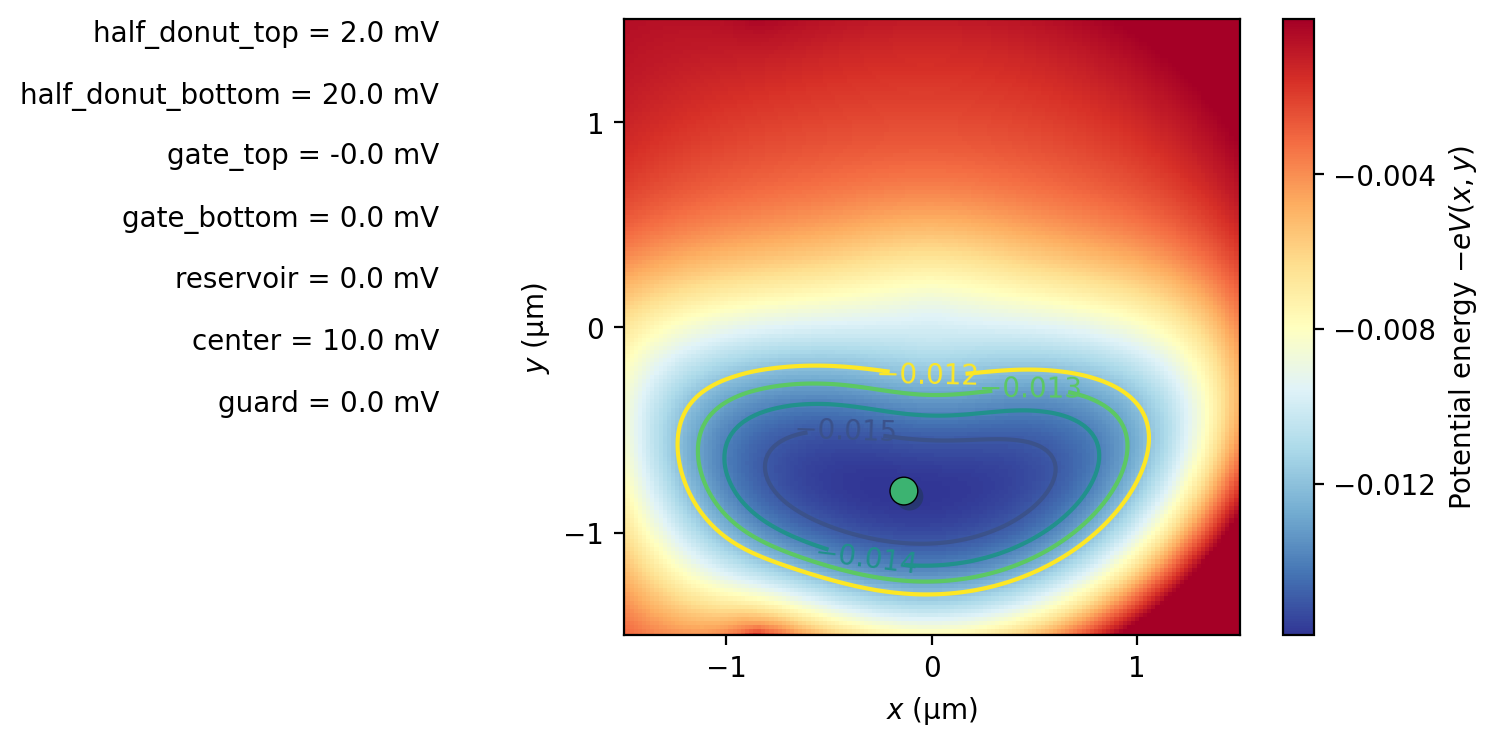

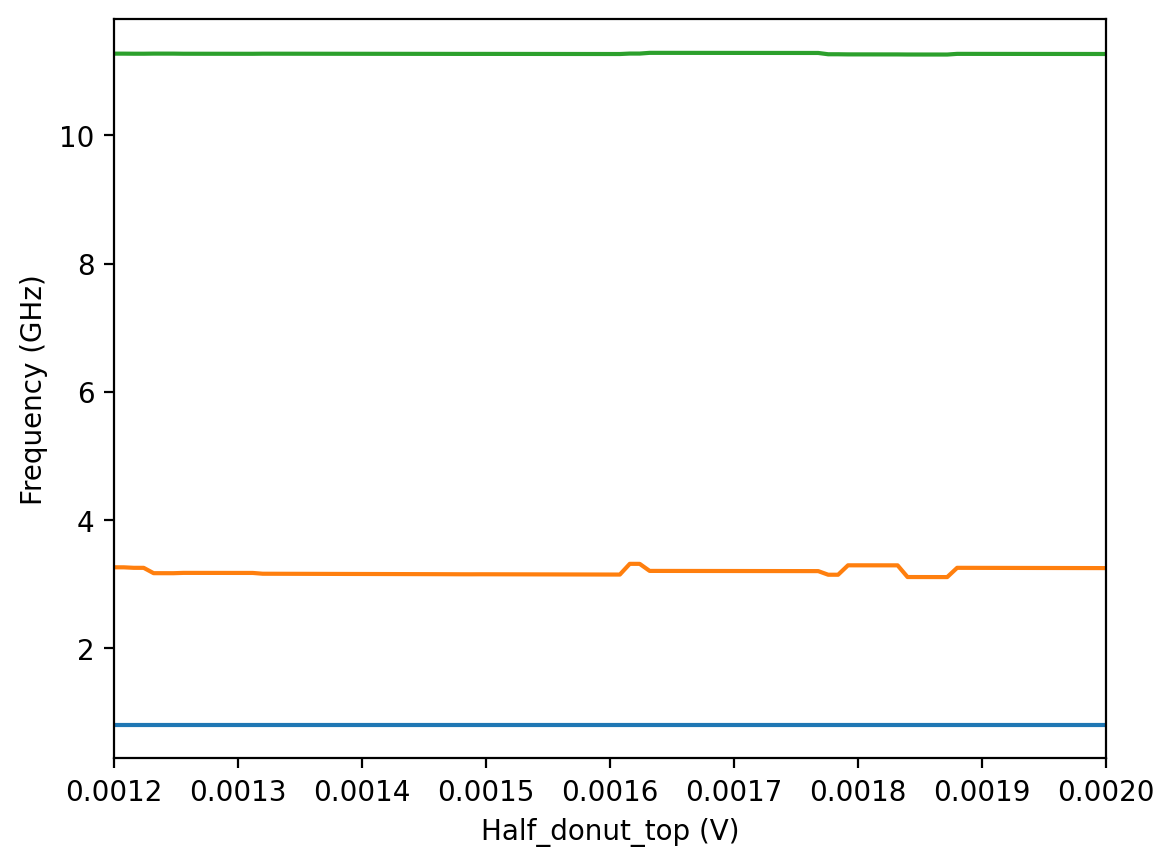

In [ ]:
sweep_voltages = np.linspace(0.0012, 0.002, 101)
eigenfrequencies = np.zeros((len(sweep_voltages), 3))
plot = True

convergence_method='L-BFGS-B' # 'L-BFGS-B' or 'Physical gradient descent'

sweep_electrode = "half_donut_top"
vi = voltages[sweep_electrode]

with alive_progress.alive_bar(len(sweep_voltages), force_tty=True) as bar:
    for k, center in enumerate(sweep_voltages):

        voltages[sweep_electrode] = center

        N = 50

        f = FullModel(trap.dot, voltages, **options)
        f.remove_unbound_electrons = False
        f.trap_annealing_steps = [0.5] * 25

        f.set_rf_interpolator(rf_electrode_labels=['guard'])


        if k == 0:
            initial_condition = f.generate_initial_condition(N)
        else:
            initial_condition = equilibrium_positions

        if convergence_method == 'L-BFGS-B':

            init_x, init_y = r2xy(initial_condition)
            res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition, verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
            equilibrium_positions= res['x']
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)
            if res['status'] != 0:
                print(f"Error at k={k}, status={res['status']}")
                print(f"Error message: {res['message']}")
                continue

        
        elif convergence_method == 'Physical gradient descent':
            n_timesteps = 6000
            dt = 1e-13 
            gamma = -0.01 * me / dt # This is the damping parameter. 
            r = np.zeros((2 * N, n_timesteps+2))

            r[:, 0] = initial_condition
            r[:, 1] = initial_condition

            for j in range(2, n_timesteps+2):
                prefactor = 1 / (me / dt ** 2 - gamma / dt)
                F = - qe * f.grad_total(r[:, j-1])
                r[:, j] = prefactor * (F - r[:, j-1] * (-2 * me / dt ** 2 + gamma / dt) - r[:, j-2] * me / dt ** 2)
                
            equilibrium_positions = r[:, -1]
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)

    


       

        # if plot and not(k%10):
        #     f.plot_potential_energy(coor=[0, 0], dxdy=(3, 3))
        #     f.plot_electron_positions(res)

        # added: resonaotor_dict
    

        K, M = f.setup_eom(equilibrium_positions, resonator_dict=resonator_dict)
        eigenfrequencies[k, :], evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)

        bar()




plt.figure()
plt.plot(sweep_voltages, eigenfrequencies / 1e9)
plt.xlabel(" Voltages (V)")
plt.ylabel("Frequency (GHz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

[7.99999977e+08 4.67440870e+09 1.08496049e+10 6.69986487e+09
 9.95985279e+09]


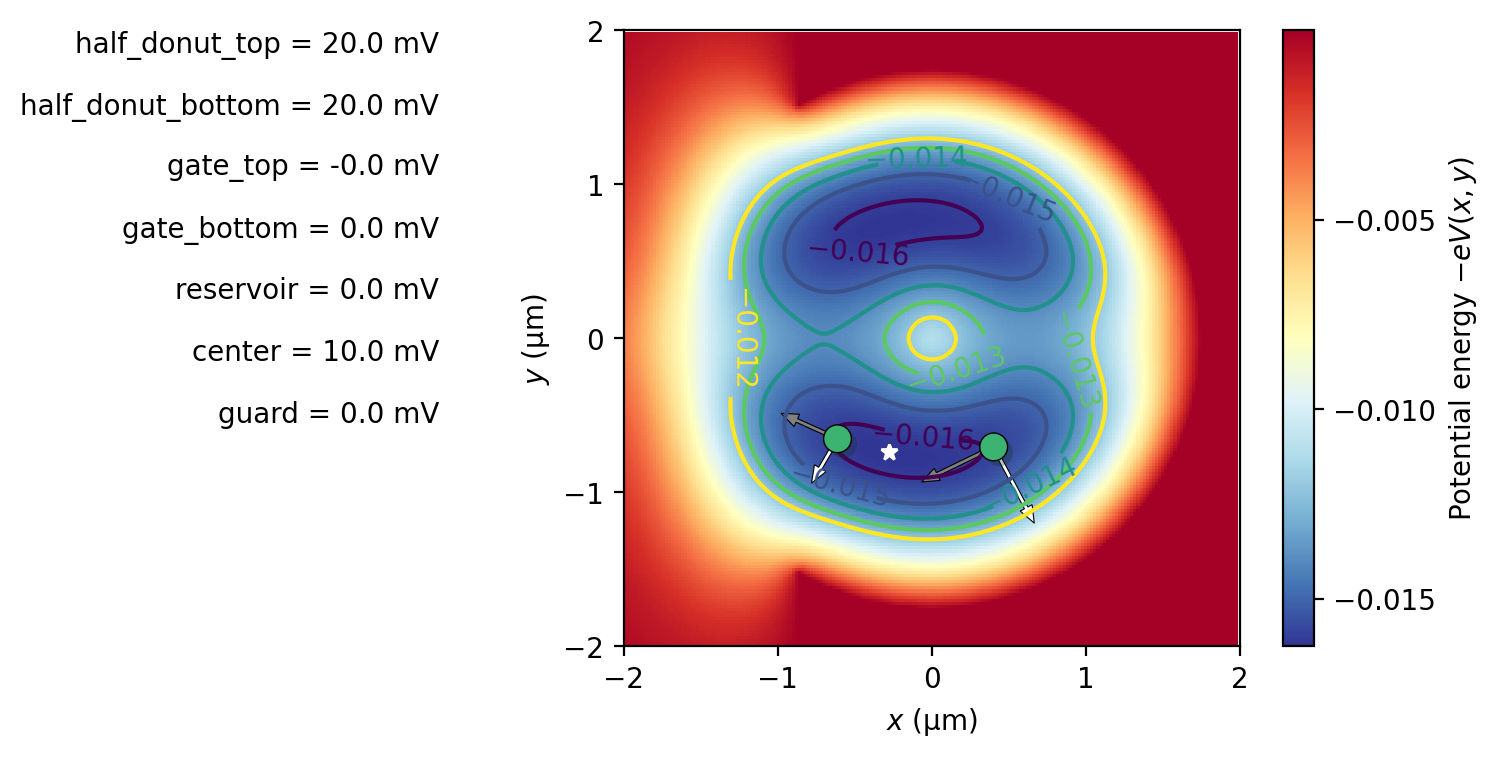

In [ ]:
N = 2

f = FullModel(trap.dot, voltages, **options)
f.remove_unbound_electrons = False
f.trap_annealing_steps = [4] * 25

f.set_rf_interpolator(rf_electrode_labels=['guard'])

initial_condition = f.generate_initial_condition(N)
init_x, init_y = r2xy(initial_condition)

res = f.get_electron_positions(n_electrons=N, electron_initial_positions=None, verbose=False)

final_x, final_y = r2xy(res['x'])

f.plot_potential_energy(coor=[0, 0], dxdy=(4, 4))
f.plot_electron_positions(res)


K, M = f.setup_eom(res['x'], resonator_dict=resonator_dict)
eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)
f.plot_eigenvector(res['x'], evecs[:, 2], color='white')
f.plot_eigenvector(res['x'], evecs[:, 1], color='gray')

print(eigenfrequencies)

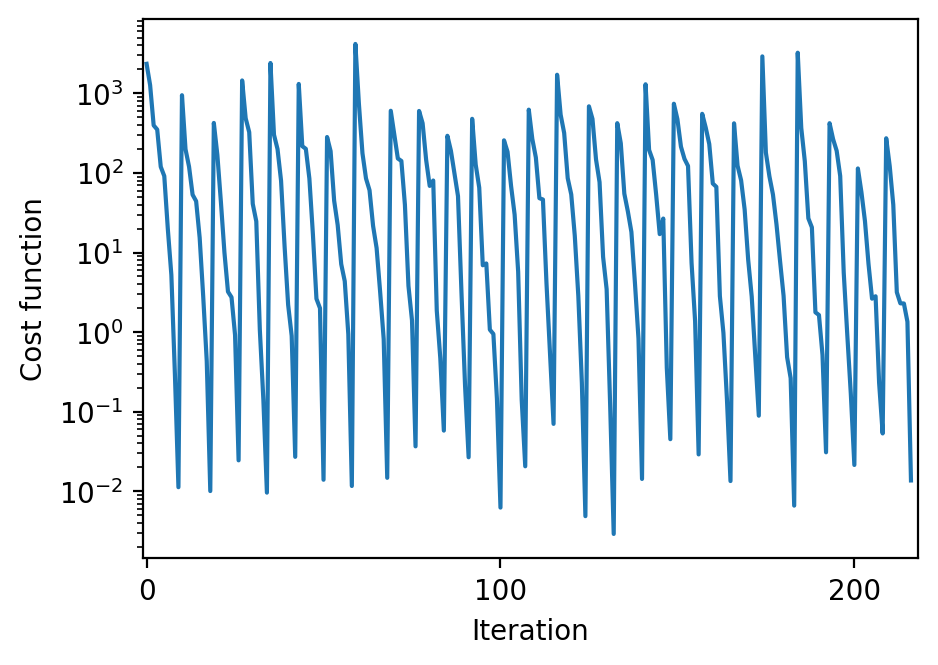

In [ ]:
f.plot_convergence()

In [ ]:
# difference between the mode most coupled to the resonator and the resonator frequency
f.get_cavity_frequency_shift(K, M)


np.float64(-23.18082332611084)

## Unloading

### Options and widgets

Potential grid: x_min=-5.00e-06, x_max=1.96e-06, y_min=-4.00e-06, y_max=3.96e-06


(-5.0, 2.0)

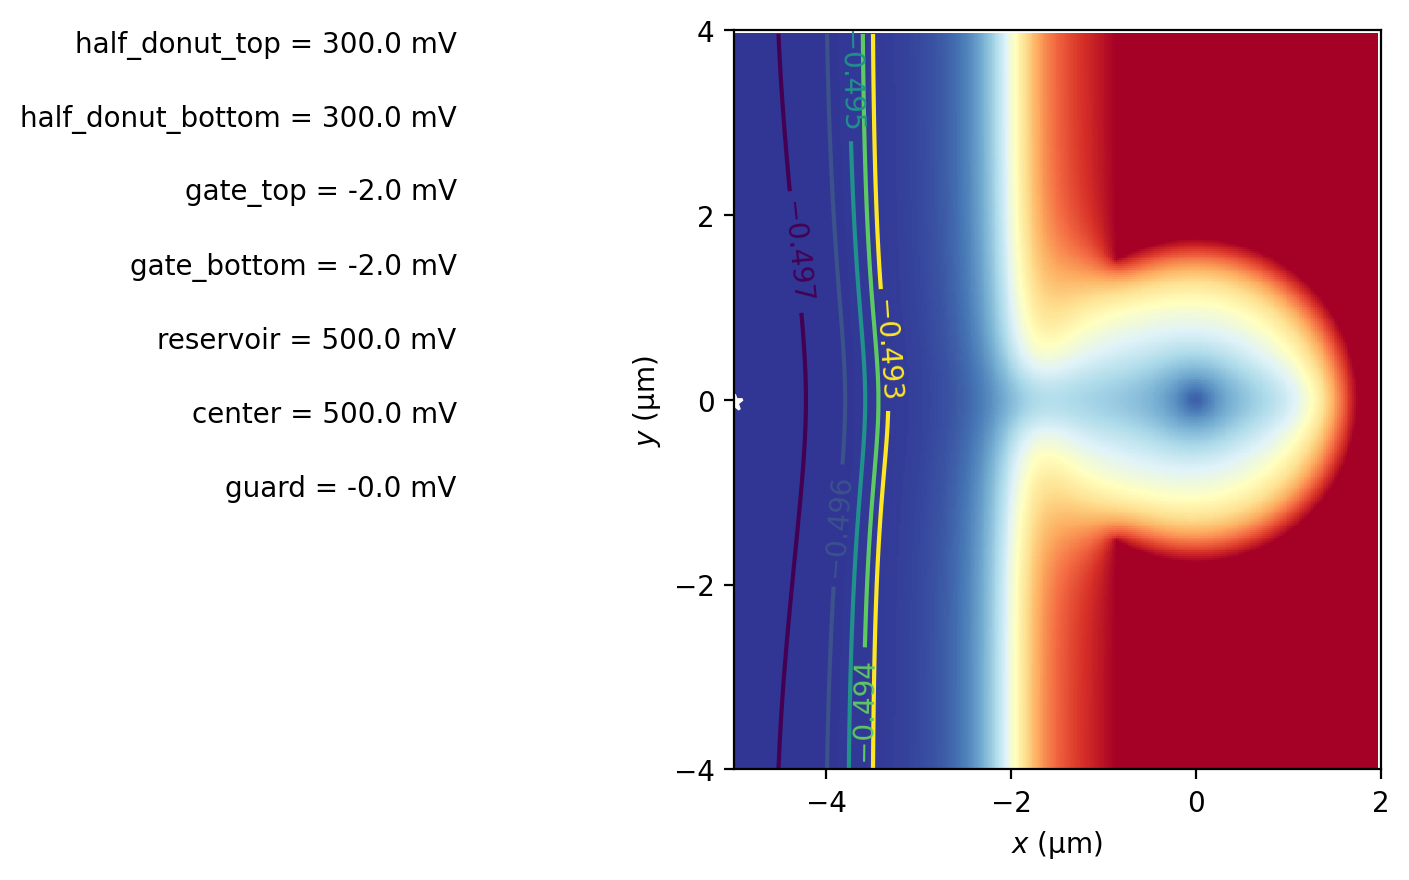

In [138]:
from quantum_electron.utils import crop_potential



left_boundary = -5 # microns

for electrode in voltages.keys():
    new_x, new_y, new_U = crop_potential(x=trap.dot['xlist'], y=trap.dot['ylist'], U=trap.dot[electrode], 
                                         xrange=(left_boundary, 2), yrange=(-4, 4))
    
    trap.dot[electrode] = new_U

trap.dot['xlist'] = new_x
trap.dot['ylist'] = new_y

x_min= np.min(trap.dot['xlist'])*1e-6
x_max= np.max(trap.dot['xlist'])*1e-6
y_min= np.min(trap.dot['ylist'])*1e-6
y_max= np.max(trap.dot['ylist'])*1e-6
print(f"Potential grid: x_min={x_min:.2e}, x_max={x_max:.2e}, y_min={y_min:.2e}, y_max={y_max:.2e}")

voltages = {
    'half_donut_top':0.3,
    'half_donut_bottom':0.3,
    'gate_top':-0.002,
    'gate_bottom':-0.002,
    'reservoir':0.5,
    'center':0.5,
    'guard':-0.000,
}
fig, ax = plt.subplots()
fm = FullModel(trap.dot, voltages)
fm.plot_potential_energy(ax=ax, coor=[0,0], dxdy=(10, 8))
ax.set_xlim(-5, 2)

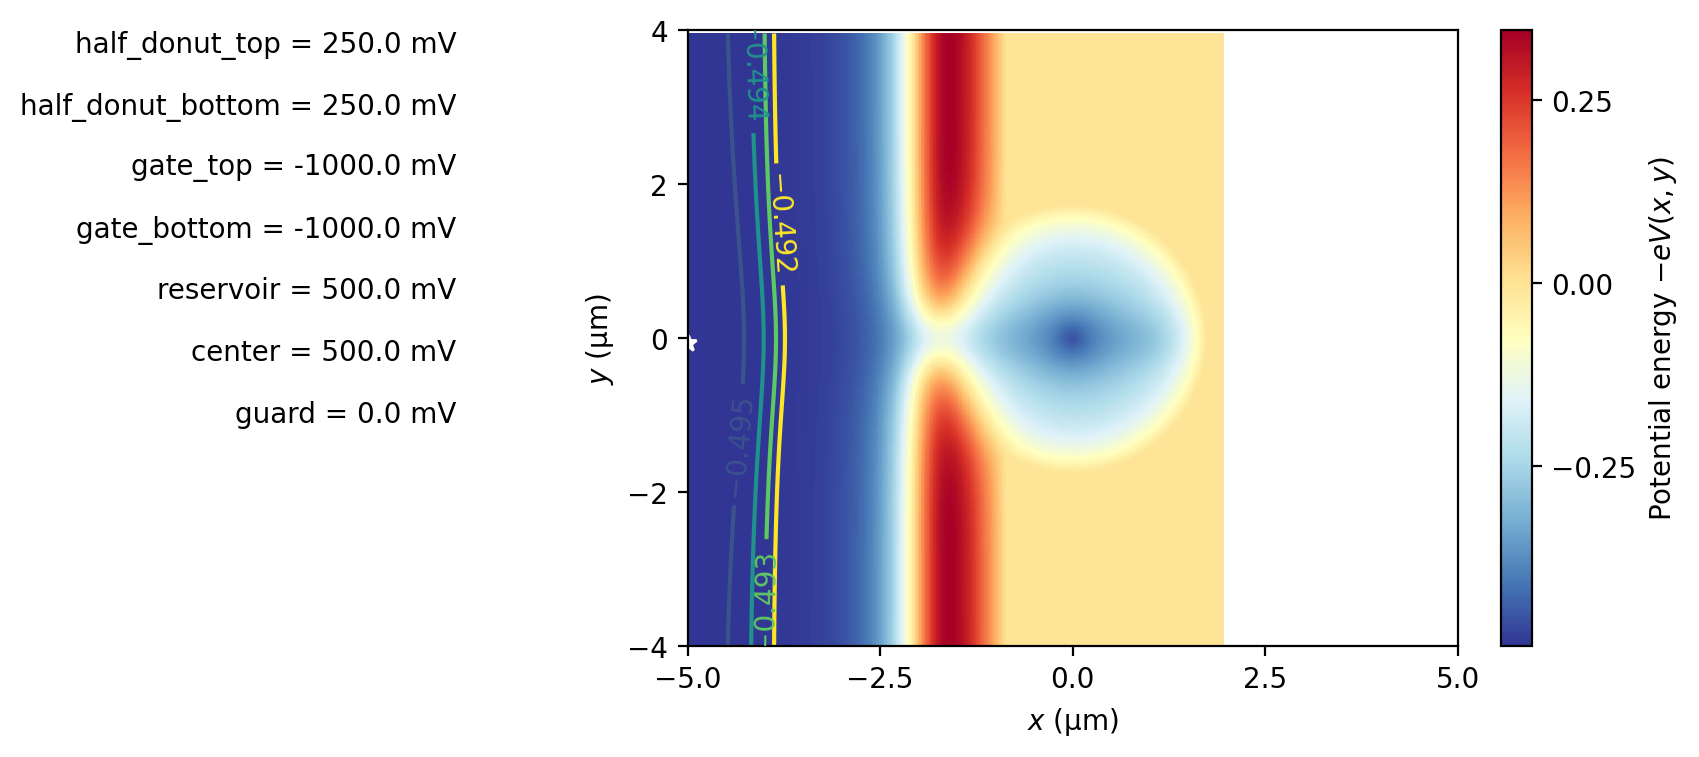

interactive(children=(FloatSlider(value=0.25, description='donuts', max=1.0, min=-0.5, step=0.001), FloatSlide…

In [140]:
Vrms = 140e-9
f0 = 0.800e9

Z = 2 / 1.055e-34 * (Vrms / (2 * np.pi * f0)) ** 2

resonator_dict = {"f0" : f0, # Resonance frequency for the resonator (only used for solving motional frequencies)
           "Z0" : Z }# Resonator impedance (only used for solving motional frequencies)
options=  { "include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : np.inf, # Typically helium thickness.
           "potential_smoothing" : 1e-3, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : True, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : (left_boundary * 1e-6, 2e-6), # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.1] * 10, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.05e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.05e-6} # Maximum y-displacement of solved electron positions during annealing.


import ipywidgets as widgets

@widgets.interact(donuts=(-0.5, 1.0, 0.001), left_guard_strips=(-1.0, 1.0, 0.001), left_reservoir=(-1.0, 1.0, 0.001), 
                  center=(-1.0, 1.0, 0.001), N=(1, 50, 1), coupled=False)
def update(donuts=0.25, left_guard_strips=-1, left_reservoir=0.5, center=0.5, N=10, coupled=False):
    if coupled: 
        center = donuts
    
        
    voltages = {
        'half_donut_top':donuts,
        'half_donut_bottom':donuts,
        'gate_top':left_guard_strips,
        'gate_bottom': left_guard_strips,
        'reservoir':left_reservoir,
        'center':center,
        'guard':0.0,
    }

    f = FullModel(trap.dot, voltages, **options)


    initial_condition = f.generate_initial_condition(N, center=(0, 0), radius=0.5e-6)
    init_x, init_y = r2xy(initial_condition)
        



    if convergence_method == 'L-BFGS-B':
        f.trap_annealing_steps = [1.0] * 25
        res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition, verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
        equilibrium_positions= res['x']

 

    
    elif convergence_method == 'Physical gradient descent':
        n_timesteps = 50000
        dt = 1e-13 
        gamma = -0.01 * me / dt # This is the damping parameter. 
        r = np.zeros((2 * N, n_timesteps+2))

        r[:, 0] = initial_condition
        r[:, 1] = initial_condition

        for j in range(2, n_timesteps+2):
            prefactor = 1 / (me / dt ** 2 - gamma / dt)
            F = - qe * f.grad_total(r[:, j-1])
            r[:, j] = prefactor * (F + r[:, j-1] * (2 * me / dt ** 2 - gamma / dt) - r[:, j-2] * me / dt ** 2)
            
        equilibrium_positions = r[:, -1]
        electron_configurations.append(equilibrium_positions)

    final_x, final_y = r2xy(equilibrium_positions)


    # qa = QuantumAnalysis(trap.dot, voltages)
    
    f.plot_potential_energy(coor=[0, 0], dxdy=(10, 8))
    f.plot_electron_positions(res)
    ax.set_xlim(-5, 2)

    dot_area = f.get_dot_area(plot=True, barrier_location=(left_boundary, 0), barrier_offset=-0.1e-3, color='k') 
    N_electrons = f.count_electrons_in_dot(equilibrium_positions, trap_bounds_x=(-1.5e-6, 1.5e-6),
                                             trap_bounds_y=(-1.5e-6, 1.5e-6))
    print(f"There are {N_electrons} in the dot, dot area = {dot_area:.2f} um^2")

### Unloading the dot

In [ ]:
# voltages = {
#     'half_donut_top':0.05,
#     'half_donut_bottom':0.05,
#     'gate_top':-0.02,
#     'gate_bottom':-0.02,
#     'reservoir':0.07,
#     'center':0.06,
#     'guard':-0.000,
# }

voltages = {
    'half_donut_top':0.005,
    'half_donut_bottom':0.005,
    'gate_top':0.005,
    'gate_bottom':0.005,
    'reservoir':0.007,
    'center':0.005,
    'guard':0.000,
}


use_previous_initial_state = True
unload_voltages = np.linspace(0.001, 0.007, 200)
list_of_voltages=[]

# Initial number of electrons to start with
N_init = 7

temperature = 1.2 # Only important for calculation of the Gamma = Ec / Ek

# Keep track of some variables
energies = np.zeros(len(unload_voltages))
num_electrons = np.zeros(len(unload_voltages))
cavity_freqs = np.zeros((len(unload_voltages), 1))
electron_configurations = []
num_electrons_chgd_disk = np.zeros(len(unload_voltages))
num_electrons_par_cap = np.zeros(len(unload_voltages))
densities = np.zeros(len(unload_voltages))
gamma_param = np.zeros(len(unload_voltages))
disc_capacitances = np.zeros(len(unload_voltages))
electron_modef = list()
trap_depth = np.zeros(len(unload_voltages))

# Choose the convergence method for the calculation of the electron positions at equilibrium.
convergence_method = 'Physical gradient descent' # 'L-BFGS-B' or 'Physical gradient descent'



with alive_progress.alive_bar(len(unload_voltages), force_tty=True) as bar:
    for k, unload in enumerate(unload_voltages):

        # Here you can change how to unload the electrons (which electrodes to sweep)
        # voltages['center'] = unload
        # voltages['half_donut_top'] = unload
        # voltages['half_donut_bottom'] = unload

        voltages['gate_top'] = unload
        voltages['gate_bottom'] = unload
        
        list_of_voltages.append(voltages.copy())
        
        f = FullModel(trap.dot, voltages, **options)

        f.set_rf_interpolator(rf_electrode_labels=['guard'])
        
        if k == 0: 
            electron_initial_positions = f.generate_initial_condition(N_init, center=(0, 0), radius=0.5e-6)
            N = N_init
        elif use_previous_initial_state: 
            electron_initial_positions = equilibrium_positions
            N = len(electron_initial_positions) // 2
        else:
            electron_initial_positions = None
            N = N_init
        
        print(N)
        if N > 0:
            if convergence_method == 'L-BFGS-B':
                res = f.get_electron_positions(n_electrons=N, 
                                            electron_initial_positions=electron_initial_positions, 
                                            verbose=False, 
                                            suppress_warnings=False)
                equilibrium_positions = res['x']
            
            elif convergence_method == 'Physical gradient descent':
                n_timesteps = 2500
                dt = 1e-13 
                gamma = -0.01 * me / dt # This is the damping parameter. 
                r = np.zeros((2 * N, n_timesteps+2))

                r[:, 0] = electron_initial_positions
                r[:, 1] = electron_initial_positions

                for j in range(2, n_timesteps+2):
                    # sets the electrons that are outside the potential to the boundary values
                    # r[::2, j-1] = np.clip(r[::2, j-1], x_min, x_max)
                    # r[1::2, j-1] = np.clip(r[1::2, j-1], y_min, y_max)

                    prefactor = 1 / (me / dt ** 2 - gamma / dt)
                    F = - qe * f.grad_total(r[:, j-1])
                    r_next = prefactor * (F + r[:, j-1] * (2 * me / dt ** 2 - gamma / dt) - r[:, j-2] * me / dt ** 2)
                    
                    x_next = r_next[::2]
                    y_next = r_next[1::2]

                    inside = np.logical_and.reduce((
                    x_next >= x_min, x_next <= x_max,
                    y_next >= y_min, y_next <= y_max
                ))
                    
                    r_filtered = np.empty((2 * np.sum(inside), j + 1))

                    for step in range(j):
                        x = r[::2, step][inside]
                        y = r[1::2, step][inside]
                        r_filtered[::2, step] = x
                        r_filtered[1::2, step] = y

                    # add the new column
                    r_filtered[::2, j] = x_next[inside]
                    r_filtered[1::2, j] = y_next[inside]

                    # Update the remaining electrons
                    r = r_filtered


                print("The gradient norm is:", np.linalg.norm(f.grad_total(r[:, -1])))
                equilibrium_positions = r[:, -1]


                

            num_electrons[k] = f.count_electrons_in_dot(equilibrium_positions, trap_bounds_x=(-1.5*1e-6,1.5*1e-6), trap_bounds_y=(-1.5*1e-6,1.5*1e-6)) #if trap_bounds_x,y is not specified, the default value is (-1e-6, 1e-6) for both x and y.
            final_x, final_y = r2xy(equilibrium_positions)
            electron_configurations.append(equilibrium_positions)
            
            if len(final_x) == 1:
                poly_area = np.nan
                disc_capacitances[k] = 8 * 8.85e-12 * np.sqrt(poly_area / np.pi)
            
            if len(final_x) > 1:
                densities[k] = density_from_positions(final_x, final_y)
            
                # Estimate the number of electrons from a charged disk assumption:
                # See the following reference: https://arxiv.org/pdf/cond-mat/0405084.pdf
                Rx = .5 * (np.max(final_x) - np.min(final_x))
                Ry = .5 * (np.max(final_y) - np.min(final_y))    

                if len(final_x) > 2:
                    # Need at least 3 points to span a surface
                    poly_pts, poly_area = select_outer_electrons(final_x, final_y, color='k', plot=False)
                    poly_area *= 1e-12
                elif len(final_x) == 2: 
                    poly_area == np.nan
                
                try:
                    dot_area = f.get_dot_area(plot=False, barrier_location=(left_boundary, 0), barrier_offset=-0.2e-3, color='k') * 1e-12
                except:
                    dot_area = 0.0
                
                # Determine the effective radius of the charged disk.
                R = np.sqrt(dot_area / np.pi) #poly_area
                C = 8 * 8.85e-12 * R
                t_he = 0.5e-6

                _, _, eVmin = find_minimum_location(trap.dot, voltages, return_potential_value=True)  

                # Location of the barrier to the trap = (-1.7, 0.0)
                potential = make_potential(trap.dot, voltages)

                # Check the barrier height around the dot
                dot_barriers = list()
                for check_x, check_y in [(left_boundary, 0.0), (0.0, 2.0), (2.0, 0.0)]:
                    idx = find_nearest(trap.dot['ylist'], check_y)
                    idy = find_nearest(trap.dot['xlist'], check_x)
                    barrier_height = -potential[idy, idx]
                    dot_barriers.append(barrier_height)

                V = np.min(dot_barriers) - eVmin
                trap_depth[k] = V  
                num_electrons_chgd_disk[k] = int(np.ceil(C * V / 1.602e-19))
                disc_capacitances[k] = 8 * 8.85e-12 * np.sqrt(poly_area / np.pi)
                num_electrons_par_cap[k] = int(np.ceil(8.85e-12 * dot_area / t_he * V / 1.602e-19))
                gamma_param[k] = 0.0 #utils.gamma_parameter(final_x, final_y, temperature)
        else:
            electron_configurations.append([])
        
        K, M = f.setup_eom(equilibrium_positions, resonator_dict)
        eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)
        
        if len(equilibrium_positions) > 1:
            electron_modef.append(eigenfrequencies[1])
        else:
            electron_modef.append(np.nan)
        
        cavity_freqs[k, :] = eigenfrequencies[0]        
        
        bar()


on 0: 7                                                                         
on 0: The gradient norm is: 1658.009965879796                                   


on 0: C:\Users\riken\Desktop\Folder_Thomas\Quantum_Eigensolver\quantum_electron\quantum_electron\eom_solver.py:321: RuntimeWarning: invalid value encountered in sqrt
        return np.sqrt(EVals) / (2 * np.pi), EVecs


on 1: 7                                                                         
on 1: The gradient norm is: 3867.9373969312696                                  
on 2: 7                                                                         
on 2: The gradient norm is: 1436.735562317264                                   
on 3: 7                                                                         
on 3: The gradient norm is: 1158.6192947996922                                  
on 4: 7                                                                         
on 4: The gradient norm is: 994.448424184191                                    
on 5: 7                                                                         
on 5: The gradient norm is: 851.2159278007719                                   
on 6: 7                                                                         
on 6: The gradient norm is: 743.2145015148961                                   
on 7: 7                     

### Animates the voltage sweep

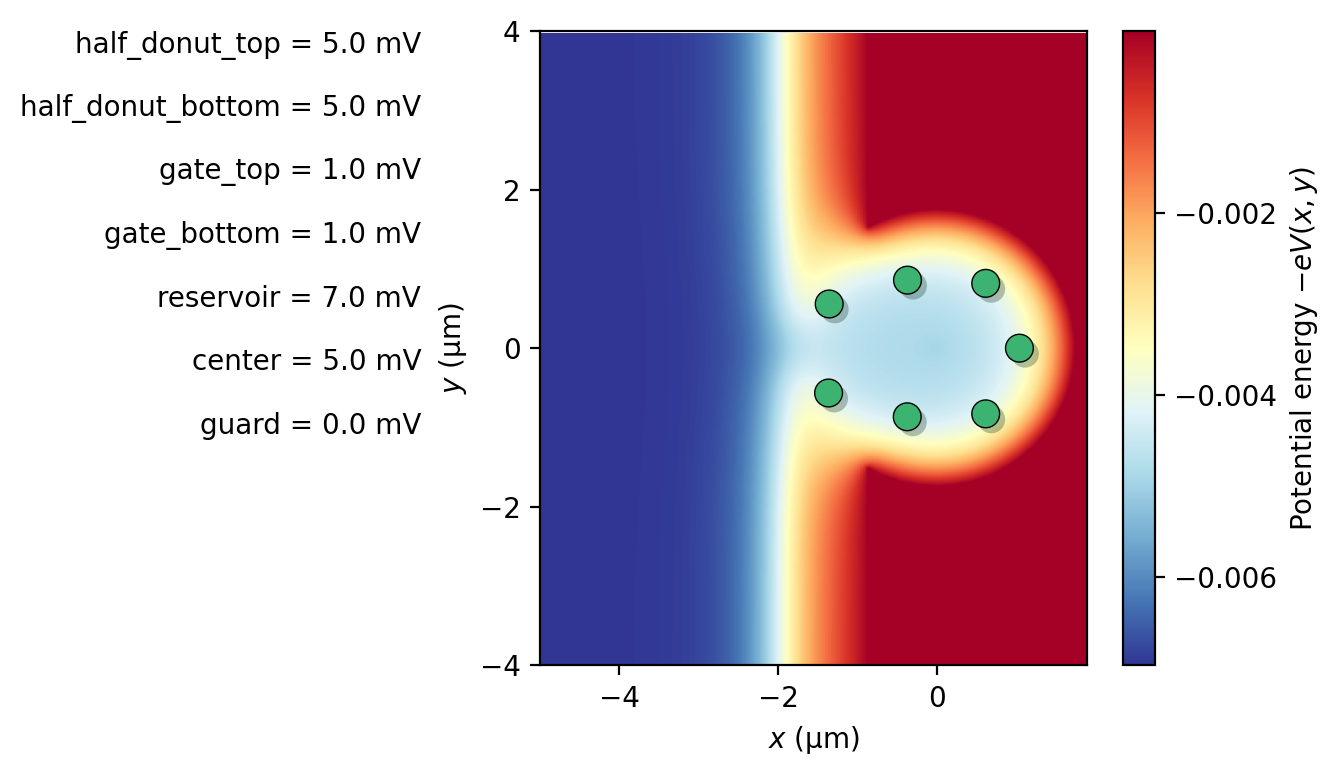

In [148]:
fig, ax = plt.subplots(figsize=(7, 4.))

anim = f.animate_voltage_sweep(fig, ax,  list_of_voltages=list_of_voltages, list_of_electron_positions=electron_configurations,
                            dxdy=(10, 8), frame_interval_ms=100 )
ax.set_xlim(-5, 1.9)
f.show_animation(anim)

### Plot the number of electrons and the frequency shifts

In [155]:
%matplotlib notebook
fig, ax1 = plt.subplots(figsize=(7, 5))

# Courbes sur l'axe de gauche (nombre d'électrons)
ax1.step(unload_voltages, num_electrons, label="Individual electron minimization")
# ax1.step(unload_voltages, num_electrons_chgd_disk, label="Charged disk approx.")
# ax1.step(unload_voltages, num_electrons_par_cap, label="Parallel capacitor approach")
ax1.set_xlabel("Top and bottom gate voltage [V]")
ax1.set_ylabel("Number of electrons")
ax1.set_xlim(np.min(unload_voltages), np.max(unload_voltages))
# ax1.set_xlim(np.min(unload_voltages),0.05)
ax1.legend(loc=0, frameon=False)

# Deuxième axe à droite pour la fréquence résonante
ax2 = ax1.twinx()
ax2.plot(unload_voltages, cavity_freqs, 'r--', label="Cavity frequency")
ax2.set_ylabel("Resonance frequency [Hz]")
ax2.spines["right"].set_position(("axes", 1.1))  # Décale le deuxième axe à droite
ax2.set_xlim(np.min(unload_voltages), np.max(unload_voltages))
ax2.set_ylim()
# ax1.set_xlim(np.min(unload_voltages),0.05)

# Troisième axe à droite pour la profondeur du piège
# ax3 = ax1.twinx()
# ax3.plot(unload_voltages, trap_depth * 1e3, 'k--', label="Trap depth")
# ax3.set_ylabel("Trap depth (meV)")
# ax3.spines["right"].set_position(("axes", 1.2))  # Décale le troisième axe à droite
# ax3.set_xlim(np.min(unload_voltages), np.max(unload_voltages))

plt.tight_layout()
plt.show()



<IPython.core.display.Javascript object>